# Null Space Analysis

This notebook will extract and analyze neuron spiking data from NWB files.


In [204]:
import os
from pathlib import Path
from pynwb import NWBHDF5IO
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Set up paths
data_root = Path("/Users/jundazhu/SBCAT/000469")


## All Functions

All functions are defined below, organized by category:
- **Trial Selection**: Select trials by load, correctness, probe in/out, or indices
- **File Listing**: List and select NWB files
- **Data Extraction**: Extract spike data and trial information from NWB files
- **DataFrame Creation**: Convert extraction results to DataFrames
- **Spike Segmentation**: Segment spikes by trials, aligned to specific events
- **Workflow**: Process single or multiple sessions

In [205]:
def select_trials_by_load(trials_df, load_values):
    """
    Select trials by memory load values (session-level).
    Args:
        trials_df: DataFrame with trial info
        load_values: int or list of int (e.g., 1, or [1,3])
    Returns:
        selected_trials_df: Filtered DataFrame
        selected_indices: np.array of row indices selected
    """
    if 'loads' not in trials_df.columns:
        raise ValueError("trials_df must have a 'loads' column")
    if not isinstance(load_values, (list, tuple, np.ndarray)):
        load_values = [load_values]
    mask = trials_df['loads'].isin(load_values)
    selected_indices = np.where(mask)[0]
    selected_trials_df = trials_df.iloc[selected_indices].copy()
    return selected_trials_df, selected_indices

def select_trials_by_correctness(trials_df, correct_only=True):
    """
    Select trials by correctness.
    Args:
        trials_df: DataFrame
        correct_only: bool
    Returns:
        selected_trials_df: Filtered DataFrame
        selected_indices: np.array of selected
    """
    if 'response_accuracy' not in trials_df.columns:
        raise ValueError("trials_df must have a 'response_accuracy' column")
    mask = (trials_df['response_accuracy'] == 1) if correct_only else (trials_df['response_accuracy'] != 1)
    selected_indices = np.where(mask)[0]
    selected_trials_df = trials_df.iloc[selected_indices].copy()
    return selected_trials_df, selected_indices
def list_available_files(data_dir, session_filter=None):
    """List all available NWB files with indices for selection.
    Args:
        data_dir: path object or string to root dir
        session_filter: 'ses-1', 'ses-2', or None
    Returns:
        files: list of Path
    """
    files = sorted(data_dir.rglob("*.nwb"))
    if session_filter in ["ses-1", "ses-2"]:
        files = [f for f in files if session_filter in f.name]
        print(f"Found {len(files)} NWB files (session filter = {session_filter}):\n")
    else:
        print(f"Found {len(files)} NWB files:\n")
    for i, f in enumerate(files):
        rel_path = f.relative_to(data_dir)
        print(f"{i:3d}. {rel_path}")
    return files

def extract_spike_data(filepath, include_waveforms=False, quality_filters=None, include_trials=True):
    """
    Extract spike data from an NWB file.
    Args:
        filepath: Path object or string for file.
        include_waveforms: bool
        quality_filters: dict
        include_trials: bool
    Returns:
        dict with
          - 'filepath'
          - 'subject_id'
          - 'session_id'
          - 'units': list of dict
          - 'trials': DataFrame or None
    """
    filepath = Path(filepath)
    # Subject/session from file name
    parts = filepath.stem.split('_')
    subject_id = None
    session_id = None
    for part in parts:
        if part.startswith('sub-'):
            subject_id = int(part.split('-')[1])
        elif part.startswith('ses-'):
            session_id = int(part.split('-')[1])
    result = {
        'filepath': str(filepath),
        'subject_id': subject_id,
        'session_id': session_id,
        'units': []
    }
    try:
        with NWBHDF5IO(str(filepath), mode="r", load_namespaces=True) as io:
            nwbf = io.read()
            # trials
            if include_trials and nwbf.trials is not None:
                try:
                    trials_df = nwbf.trials.to_dataframe()
                    result['trials'] = trials_df
                except Exception as e:
                    print(f"Warning: Could not extract trials from {filepath.name}: {e}")
                    result['trials'] = None
            else:
                result['trials'] = None
            if nwbf.units is None:
                print(f"Warning: No units found in {filepath.name}")
                return result
            units_df = nwbf.units.to_dataframe()
            electrodes_df = nwbf.electrodes.to_dataframe() if nwbf.electrodes is not None else None
            for unit_idx in units_df.index:
                unit_data = {
                    'unit_id': int(unit_idx),
                    'spike_times': None,
                    'electrode_idx': None,
                    'cluster_id': None,
                    'mean_snr': None,
                    'peak_snr': None,
                    'isolation_distance': None,
                    'mean_proj_dist': None,
                    'n_spikes': 0,
                    'brain_region': None
                }
                # spike times
                try:
                    spike_times = np.array(nwbf.units['spike_times'][unit_idx][:])
                    unit_data['spike_times'] = spike_times
                    unit_data['n_spikes'] = len(spike_times)
                except Exception as e:
                    print(f"Warning: Could not extract spike times for unit {unit_idx}: {e}")
                    continue
                # electrode info
                if 'electrodes' in units_df.columns:
                    try:
                        electrode_info = units_df.loc[unit_idx, 'electrodes']
                        if hasattr(electrode_info, 'index'):
                            unit_data['electrode_idx'] = int(electrode_info.index[0]) if len(electrode_info.index) > 0 else None
                        else:
                            unit_data['electrode_idx'] = int(electrode_info) if pd.notna(electrode_info) else None
                        if unit_data['electrode_idx'] is not None and electrodes_df is not None:
                            if 'location' in electrodes_df.columns:
                                unit_data['brain_region'] = electrodes_df.loc[unit_data['electrode_idx'], 'location']
                    except Exception:
                        pass
                # quality metrics
                if 'clusterID_orig' in units_df.columns:
                    unit_data['cluster_id'] = units_df.loc[unit_idx, 'clusterID_orig']
                if 'waveforms_mean_snr' in units_df.columns:
                    unit_data['mean_snr'] = units_df.loc[unit_idx, 'waveforms_mean_snr']
                if 'waveforms_peak_snr' in units_df.columns:
                    unit_data['peak_snr'] = units_df.loc[unit_idx, 'waveforms_peak_snr']
                if 'waveforms_isolation_distance' in units_df.columns:
                    unit_data['isolation_distance'] = units_df.loc[unit_idx, 'waveforms_isolation_distance']
                if 'waveforms_mean_proj_dist' in units_df.columns:
                    unit_data['mean_proj_dist'] = units_df.loc[unit_idx, 'waveforms_mean_proj_dist']
                # filter
                if quality_filters is not None:
                    skip_unit = False
                    if 'min_snr' in quality_filters and unit_data['mean_snr'] is not None:
                        if unit_data['mean_snr'] < quality_filters['min_snr']:
                            skip_unit = True
                    if 'min_isolation_distance' in quality_filters and unit_data['isolation_distance'] is not None:
                        if unit_data['isolation_distance'] < quality_filters['min_isolation_distance']:
                            skip_unit = True
                    if 'min_n_spikes' in quality_filters:
                        if unit_data['n_spikes'] < quality_filters['min_n_spikes']:
                            skip_unit = True
                    if skip_unit:
                        continue
                # waveforms
                if include_waveforms and 'waveforms' in units_df.columns:
                    try:
                        waveforms = np.array(nwbf.units['waveforms'][unit_idx][:])
                        unit_data['waveforms'] = waveforms
                    except Exception:
                        pass
                result['units'].append(unit_data)
    except Exception as e:
        print(f"Error processing {filepath.name}: {e}")
        import traceback
        traceback.print_exc()
    return result
def segment_spikes_by_trials(spike_times, trials_df, align_to='start_time', time_window=None):
    """
    Segment spikes by trials, aligned to align_to column.
    Args:
        spike_times: 1D array
        trials_df: DataFrame
        align_to: str, column to align to
        time_window: (start_offset, end_offset) or None
    Returns:
        list of arrays, one per trial (aligned)
    """
    segmented_spikes = []
    for trial_idx, trial in trials_df.iterrows():
        if align_to in trial and pd.notna(trial[align_to]) and trial[align_to] > 0:
            alignment_point = trial[align_to]
        elif 'start_time' in trial:
            alignment_point = trial['start_time']
        else:
            segmented_spikes.append(np.array([]))
            continue
        if time_window is not None:
            window_start = alignment_point + time_window[0]
            window_end = alignment_point + time_window[1]
        else:
            window_start = trial.get('start_time', alignment_point)
            window_end = trial.get('stop_time', alignment_point + 10.0)
        mask = (spike_times >= window_start) & (spike_times < window_end)
        trial_spikes = spike_times[mask]
        aligned_spikes = trial_spikes - alignment_point
        segmented_spikes.append(aligned_spikes)
    return segmented_spikes

def segment_spikes_by_selected_trials(spike_times, trials_df, selected_trial_indices=None,
                                      align_to='start_time', time_window=None):
    """
    Segment spikes for selected trials, as above but possibly a subset.
    Args:
        spike_times: 1D array
        trials_df: DataFrame
        selected_trial_indices: indices or None
        align_to: str
        time_window: tuple or None
    Returns:
        list of arrays, one per selected trial (aligned)
    """
    if selected_trial_indices is not None:
        selected_trials_df = trials_df.iloc[selected_trial_indices].copy()
        selected_trials_df = selected_trials_df.reset_index(drop=True)
    else:
        selected_trials_df = trials_df
    return segment_spikes_by_trials(
        spike_times,
        selected_trials_df,
        align_to=align_to,
        time_window=time_window
    )
def create_unit_metadata_df(extraction_result):
    """
    DataFrame of all metadata for each unit (no spikes).
    Args:
        extraction_result: result from extract_spike_data
    Returns:
        DataFrame
    """
    unit_rows = []
    for unit in extraction_result['units']:
        row = {
            'subject_id': extraction_result['subject_id'],
            'session_id': extraction_result['session_id'],
            'filepath': extraction_result['filepath'],
            'unit_id': unit['unit_id'],
            'n_spikes': unit['n_spikes'],
            'electrode_idx': unit['electrode_idx'],
            'brain_region': unit['brain_region'],
            'cluster_id': unit['cluster_id'],
            'mean_snr': unit['mean_snr'],
            'peak_snr': unit['peak_snr'],
            'isolation_distance': unit['isolation_distance'],
            'mean_proj_dist': unit['mean_proj_dist']
        }
        unit_rows.append(row)
    return pd.DataFrame(unit_rows)
def collapse_hemispheres(compiled_df, inplace=False):
    """
    Collapse left/right hemispheres for brain_region. Adds 'brain_region_collapsed' column.
    Args:
        compiled_df: DataFrame
        inplace: bool
    Returns:
        DataFrame with 'brain_region_collapsed'
    """
    if 'brain_region' not in compiled_df.columns:
        raise ValueError("DataFrame must have a 'brain_region' column")
    df = compiled_df if inplace else compiled_df.copy()
    def collapse_region(region):
        if pd.isna(region) or region is None:
            return region
        region_str = str(region).strip()
        if region_str.lower().endswith('_left'):
            return region_str[:-5]
        elif region_str.lower().endswith('_right'):
            return region_str[:-6]
        else:
            return region_str
    df['brain_region_collapsed'] = df['brain_region'].apply(collapse_region)
    return df

def list_available_brain_regions(compiled_df, show_collapsed=True):
    """
    Print all unique regions (and collapsed regions, if requested).
    Args:
        compiled_df: DataFrame with 'brain_region'
        show_collapsed: bool
    Returns:
        (original_regions, collapsed_regions)
    """
    if 'brain_region' not in compiled_df.columns:
        raise ValueError("DataFrame must have a 'brain_region' column")
    original_regions = compiled_df['brain_region'].dropna().unique()
    original_regions = sorted([str(r) for r in original_regions if r is not None])
    print("=== Available Brain Regions ===")
    print(f"\nOriginal regions ({len(original_regions)}):")
    for i, region in enumerate(original_regions, 1):
        count = len(compiled_df[compiled_df['brain_region'] == region])
        print(f"  {i:2d}. {region:30s} ({count} units)")
    if show_collapsed:
        if 'brain_region_collapsed' not in compiled_df.columns:
            df_temp = collapse_hemispheres(compiled_df.copy())
        else:
            df_temp = compiled_df
        collapsed_regions = df_temp['brain_region_collapsed'].dropna().unique()
        collapsed_regions = sorted([str(r) for r in collapsed_regions if r is not None])
        print(f"\nCollapsed regions ({len(collapsed_regions)}):")
        for i, region in enumerate(collapsed_regions, 1):
            count = len(df_temp[df_temp['brain_region_collapsed'] == region])
            print(f"  {i:2d}. {region:30s} ({count} units)")
        return original_regions, collapsed_regions
    return original_regions, None

def select_units_by_brain_region(compiled_df, brain_regions, match_type='exact', use_collapsed=True):
    """
    Select units by brain region.
    Args:
        compiled_df: DataFrame
        brain_regions: str or list
        match_type: 'exact' or 'contains'
        use_collapsed: bool
    Returns:
        filtered_df: DataFrame
    """
    if 'brain_region' not in compiled_df.columns:
        raise ValueError("DataFrame must have a 'brain_region' column")
    if use_collapsed:
        if 'brain_region_collapsed' not in compiled_df.columns:
            compiled_df = collapse_hemispheres(compiled_df.copy())
        region_col = 'brain_region_collapsed'
    else:
        region_col = 'brain_region'
    if isinstance(brain_regions, str):
        brain_regions = [brain_regions]
    if match_type == 'exact':
        mask = compiled_df[region_col].isin(brain_regions)
    elif match_type == 'contains':
        mask = compiled_df[region_col].astype(str).str.contains(
            '|'.join(brain_regions), case=False, na=False, regex=True
        )
    else:
        raise ValueError(f"Unknown match_type: {match_type}. Use 'exact' or 'contains'")
    filtered_df = compiled_df[mask].copy()
    return filtered_df

def assign_trial_conditions_per_unit(trials_df, encoding_epoch=1, 
                                     selected_trial_indices=None, n_conditions=5):
    """
    Assign each trial a 0-based condition index based on stimulus number (1..n_conditions).
    Ensures a fixed condition axis across sessions; missing/invalid IDs map to 0.
    Args:
        trials_df: DataFrame
        encoding_epoch: 1 or 3
        selected_trial_indices: indices or None
        n_conditions: total number of stimulus conditions (default 5)
    Returns:
        trial_conditions: np.array of length n_trials (0-based condition index)
    """
    pic_col = 'loadsEnc1_PicIDs' if encoding_epoch == 1 else 'loadsEnc3_PicIDs'
    trials_subset = trials_df.iloc[selected_trial_indices] if selected_trial_indices is not None else trials_df

    def map_pic_id(pic_id):
        if pd.isna(pic_id) or pic_id is None:
            return 0
        try:
            pid = int(pic_id)
        except Exception:
            return 0
        if pid <= 0:
            return 0
        idx = pid - 1
        # Clamp to configured condition count to avoid out-of-range indices
        return min(idx, n_conditions - 1)

    trial_conditions = np.array([map_pic_id(pic_id) for pic_id in trials_subset[pic_col]])
    return trial_conditions

def compute_mean_rate_hz(segmented_spikes, time_window):
    """
    Compute mean firing rate (Hz) across selected trials for one unit.
    Args:
        segmented_spikes: list of arrays, one per selected trial
        time_window: tuple (start, end) defining alignment window
    Returns:
        mean_rate_hz: float (spikes/sec), or np.nan if not computable
    """
    if time_window is None:
        return np.nan
    window_start, window_end = time_window
    window_duration = window_end - window_start
    if window_duration <= 0:
        return np.nan
    total_spikes = sum(len(trial) for trial in segmented_spikes)
    total_time = len(segmented_spikes) * window_duration
    if total_time <= 0:
        return np.nan
    return total_spikes / total_time


def build_firing_rate_matrix_per_unit(segmented_spikes, trial_conditions, n_conditions,
                                      bin_size=0.02, time_range=None):
    """
    Build a unit's per-condition × timebin matrix (1 vector) using raw binned rates.
    Args:
        segmented_spikes: list of arrays, one per trial
        trial_conditions: np.array, int index per trial
        n_conditions: int
        bin_size: float, seconds
        time_range: (start, end) or None
    Returns:
        row_vector: 1D np.array (n_conditions * n_bins)
        bin_edges: np.array
    """
    if time_range is None:
        all_times = []
        for trial_spikes in segmented_spikes:
            if len(trial_spikes) > 0:
                all_times.extend(trial_spikes)
        if len(all_times) == 0:
            time_range = (0, 1)
        else:
            time_range = (min(all_times), max(all_times))
    start_time, end_time = time_range
    n_bins = int(np.ceil((end_time - start_time) / bin_size))
    bin_edges = np.linspace(start_time, end_time, n_bins + 1)
    row_vector = np.zeros(n_conditions * n_bins)
    for cond_idx in range(n_conditions):
        cond_mask = trial_conditions == cond_idx
        cond_trial_indices = np.where(cond_mask)[0]
        if len(cond_trial_indices) == 0:
            continue
        trial_binned = []
        for trial_idx in cond_trial_indices:
            trial_spikes = segmented_spikes[trial_idx]
            if len(trial_spikes) > 0:
                counts, _ = np.histogram(trial_spikes, bins=bin_edges)
                trial_binned.append(counts)
            else:
                trial_binned.append(np.zeros(n_bins))
        if len(trial_binned) > 0:
            cond_mean = np.mean(trial_binned, axis=0)
            start_col = cond_idx * n_bins
            end_col = (cond_idx + 1) * n_bins
            row_vector[start_col:end_col] = cond_mean
    return row_vector, bin_edges
def process_session_condition_based(filepath, selected_trial_indices=None, align_to='start_time', 
                                    time_window=None, encoding_epoch=1,
                                    bin_size=0.01, selected_unit_ids=None, n_conditions=5,
                                    min_mean_rate_hz=None):
    """
    Process one session; returns condition-based firing rate matrix for units.
    Args:
        filepath: file
        selected_trial_indices: indices or None
        align_to: str (column in trials_df)
        time_window: tuple or None
        encoding_epoch: 1 or 3
        bin_size: float
        selected_unit_ids: list of (subject_id, session_id, unit_id) or None
        n_conditions: total number of stimulus conditions (fixed across sessions)
        min_mean_rate_hz: float or None; drop units with mean firing rate below threshold (Hz)
    Returns:
        matrix: np.array (n_units, n_conditions * n_bins)
        unit_info: DataFrame (includes mean_rate_hz for retained units)
        bin_edges: np.array
        column_labels: list of str
        condition_info: dict
    """
    result = extract_spike_data(filepath, include_trials=True)
    if result['trials'] is None or len(result['trials']) == 0:
        return None, None, None, None, None
    trials_df = result['trials'].copy().reset_index(drop=True)
    if selected_trial_indices is None:
        selected_trial_indices = np.arange(len(trials_df))
    if encoding_epoch == 1:
        pic_col = 'loadsEnc1_PicIDs'
    else:
        pic_col = 'loadsEnc3_PicIDs'

    # Compute trial conditions once for all units (same for all units in a session)
    trial_conditions = assign_trial_conditions_per_unit(
        trials_df,
        encoding_epoch=encoding_epoch,
        selected_trial_indices=selected_trial_indices,
        n_conditions=n_conditions
    )

    selected_unit_set = set(selected_unit_ids) if selected_unit_ids is not None else None
    unit_rows = []
    matrix_rows = []
    bin_edges = None
    for unit in result['units']:
        unit_identifier = (result['subject_id'], result['session_id'], unit['unit_id'])
        if selected_unit_set is not None and unit_identifier not in selected_unit_set:
            continue
        spike_times = unit['spike_times']
        segmented = segment_spikes_by_selected_trials(
            spike_times, trials_df, selected_trial_indices,
            align_to=align_to, time_window=time_window
        )
        mean_rate_hz = compute_mean_rate_hz(segmented, time_window)
        if min_mean_rate_hz is not None:
            if np.isnan(mean_rate_hz) or mean_rate_hz < min_mean_rate_hz:
                continue
        row_vector, bin_edges = build_firing_rate_matrix_per_unit(
            segmented, trial_conditions, n_conditions,
            bin_size=bin_size, time_range=time_window
        )
        matrix_rows.append(row_vector)
        unit_rows.append({
            'subject_id': result['subject_id'],
            'session_id': result['session_id'],
            'filepath': result['filepath'],
            'unit_id': unit['unit_id'],
            'n_spikes': unit['n_spikes'],
            'electrode_idx': unit['electrode_idx'],
            'brain_region': unit['brain_region'],
            'cluster_id': unit['cluster_id'],
            'mean_snr': unit['mean_snr'],
            'peak_snr': unit['peak_snr'],
            'isolation_distance': unit['isolation_distance'],
            'mean_proj_dist': unit['mean_proj_dist'],
            'mean_rate_hz': mean_rate_hz
        })
    if len(matrix_rows) == 0:
        return None, None, None, None, None
    matrix = np.vstack(matrix_rows)
    unit_info = pd.DataFrame(unit_rows)
    n_bins = len(bin_edges) - 1 if bin_edges is not None else 0
    column_labels = []
    condition_info = {}
    for cond_idx in range(n_conditions):
        start_col = cond_idx * n_bins
        end_col = (cond_idx + 1) * n_bins
        condition_info[f'cond{cond_idx}'] = slice(start_col, end_col)
        for bin_idx in range(n_bins):
            column_labels.append(f'cond{cond_idx}_t{bin_idx}')
    return matrix, unit_info, bin_edges, column_labels, condition_info


## 1. load data

### all file list

In [206]:
# List available files and select by index, with optional session filter
# session_filter options:
#   'all'   -> list all files
#   'ses-1' -> only session 1 files
#   'ses-2' -> only session 2 files
session_filter = 'ses-2'  # change as needed: 'all', 'ses-1', or 'ses-2'

# Get all files from disk, applying session_filter inside list_available_files
if session_filter == 'all':
    all_files = list_available_files(data_root)
else:
    all_files = list_available_files(data_root, session_filter=session_filter)


Found 21 NWB files (session filter = ses-2):

  0. sub-1/sub-1_ses-2_ecephys+image.nwb
  1. sub-10/sub-10_ses-2_ecephys+image.nwb
  2. sub-11/sub-11_ses-2_ecephys+image.nwb
  3. sub-12/sub-12_ses-2_ecephys+image.nwb
  4. sub-13/sub-13_ses-2_ecephys+image.nwb
  5. sub-14/sub-14_ses-2_ecephys+image.nwb
  6. sub-15/sub-15_ses-2_ecephys+image.nwb
  7. sub-16/sub-16_ses-2_ecephys+image.nwb
  8. sub-17/sub-17_ses-2_ecephys+image.nwb
  9. sub-18/sub-18_ses-2_ecephys+image.nwb
 10. sub-19/sub-19_ses-2_ecephys+image.nwb
 11. sub-2/sub-2_ses-2_ecephys+image.nwb
 12. sub-20/sub-20_ses-2_ecephys+image.nwb
 13. sub-21/sub-21_ses-2_ecephys+image.nwb
 14. sub-3/sub-3_ses-2_ecephys+image.nwb
 15. sub-4/sub-4_ses-2_ecephys+image.nwb
 16. sub-5/sub-5_ses-2_ecephys+image.nwb
 17. sub-6/sub-6_ses-2_ecephys+image.nwb
 18. sub-7/sub-7_ses-2_ecephys+image.nwb
 19. sub-8/sub-8_ses-2_ecephys+image.nwb
 20. sub-9/sub-9_ses-2_ecephys+image.nwb


In [207]:
# Select files to process from already-filtered all_files
# If selected_indices is empty [], all files in all_files will be selected
selected_indices = []  # e.g., [0, 1, 2]; leave [] to use all files

if len(selected_indices) == 0:
    selected_files = all_files
    print(f"Selected all {len(selected_files)} files to process:")
else:
    selected_files = [all_files[i] for i in selected_indices]
    print(f"Selected {len(selected_files)} files to process (manual indices):")

for f in selected_files:
    print(f"  {f.relative_to(data_root)}")

Selected all 21 files to process:
  sub-1/sub-1_ses-2_ecephys+image.nwb
  sub-10/sub-10_ses-2_ecephys+image.nwb
  sub-11/sub-11_ses-2_ecephys+image.nwb
  sub-12/sub-12_ses-2_ecephys+image.nwb
  sub-13/sub-13_ses-2_ecephys+image.nwb
  sub-14/sub-14_ses-2_ecephys+image.nwb
  sub-15/sub-15_ses-2_ecephys+image.nwb
  sub-16/sub-16_ses-2_ecephys+image.nwb
  sub-17/sub-17_ses-2_ecephys+image.nwb
  sub-18/sub-18_ses-2_ecephys+image.nwb
  sub-19/sub-19_ses-2_ecephys+image.nwb
  sub-2/sub-2_ses-2_ecephys+image.nwb
  sub-20/sub-20_ses-2_ecephys+image.nwb
  sub-21/sub-21_ses-2_ecephys+image.nwb
  sub-3/sub-3_ses-2_ecephys+image.nwb
  sub-4/sub-4_ses-2_ecephys+image.nwb
  sub-5/sub-5_ses-2_ecephys+image.nwb
  sub-6/sub-6_ses-2_ecephys+image.nwb
  sub-7/sub-7_ses-2_ecephys+image.nwb
  sub-8/sub-8_ses-2_ecephys+image.nwb
  sub-9/sub-9_ses-2_ecephys+image.nwb


## 2. Unit and Trial Selection

For each session:
1. Extract unit metadata
2. Select units (e.g., by brain region)
3. Select trials (e.g., by correctness or load)
4. Build condition-based matrices (Section 3)

**Note:** Unit and trial selection happens per session, then matrices are compiled across sessions.


In [208]:
# Define unit selection criteria (applied per session in Section 3)
# Select multiple brain regions to include in the compiled matrix
# Later in Section 5.5, filter into source and target subsets for PCA
selected_brain_regions = None  # Set to None to use all units (then filter in Section 5.5)
# Or specify a list of brain regions, e.g., ['hippocampus', 'pre_supplementary_motor_area']
# Time bin smoothing disabled; using raw binned firing rates
# Minimum mean firing rate (Hz) during maintenance; set to None to disable filtering
min_mean_rate_hz_maintenance = 1.0


# Define trial selection function: Correct trials AND load = 1
def select_correct_load1_trials(trials_df, filepath):
    """Select correct trials with load = 1 for this session."""
    # First select correct trials
    _, correct_indices = select_trials_by_correctness(trials_df, correct_only=True)
    
    # Then filter to load = 1
    correct_trials_df = trials_df.iloc[correct_indices]
    _, load1_indices_in_correct = select_trials_by_load(correct_trials_df, load_values=1)
    
    # Map back to original trial indices
    final_indices = correct_indices[load1_indices_in_correct]
    
    return final_indices


## 3. Build Firing Rate Matrices

Process sessions individually and build firing rate matrices with condition-based columns:
- **Projection epoch**: Aligned to maintenance onset, time window 0-2500 ms
- **Regression epoch**: Aligned to encoding 1 onset, time window 0-1000 ms
- Each row = one unit
- Each column = one time bin in one condition
- Conditions are based on stimulus numbers (1-5) from loadsEnc1_PicIDs/loadsEnc3_PicIDs
- To pool images from different subjects, we arbitrarily labeled the individual images of each subject as Images A–E. We then pooled the images with the same label across all subjects. Note that each subject saw a different set of pictures.
- Each value = mean spike count across trials in that condition for that unit in that bin
- Matrices are compiled vertically across sessions (all units have same number of conditions)


In [209]:
# Process sessions individually and build firing rate matrices with condition-based columns
# Projection epoch: aligned to maintenance onset, time window 0-2500 ms
# Each column = one time bin in one condition (conditions based on stimulus numbers 1-5)
print("Processing projection epoch (0-2500 ms relative to maintenance onset) per session...")
print("Using condition-based matrix: each column = condition × time bin")
session_matrices_projection = []
session_unit_infos_projection = []
column_labels_list_projection = []
condition_info_list_projection = []
total_units_projection = 0
for i, filepath in enumerate(selected_files, 1):
    print(f"\nProcessing session {i}/{len(selected_files)}: {Path(filepath).name}")
    
    # Step 1: Extract unit metadata for this session
    result = extract_spike_data(filepath, include_trials=True)
    unit_metadata = create_unit_metadata_df(result)
    
    # Step 2: Select units for this session (e.g., by brain region)
    if selected_brain_regions is not None:
        selected_units = select_units_by_brain_region(
            unit_metadata, 
            brain_regions=selected_brain_regions,
            match_type='exact',
            use_collapsed=True
        )
        selected_unit_ids = [(row['subject_id'], row['session_id'], row['unit_id']) 
                             for _, row in selected_units.iterrows()]
        print(f"  Selected {len(selected_unit_ids)} units from {selected_brain_regions}")
    else:
        selected_unit_ids = None
        print(f"  Using all {len(unit_metadata)} units")
    
    # Step 3: Select trials for this session (e.g., by correctness)
    trials_df = result['trials']
    if trials_df is None or len(trials_df) == 0:
        print(f"  Skipping: No trials found")
        continue
    
    selected_trial_indices = select_correct_load1_trials(trials_df, filepath)
    print(f"  Selected {len(selected_trial_indices)} trials (correct + load=1)")
    
    # Step 4: Build matrices for this session (selected units + selected trials)
    rate_threshold = min_mean_rate_hz_maintenance
    matrix, unit_info, bin_edges, column_labels, condition_info = process_session_condition_based(
        filepath,
        selected_unit_ids=selected_unit_ids,
        selected_trial_indices=selected_trial_indices,
        align_to='timestamps_Maintenance',
        time_window=(0, 2.5),
        encoding_epoch=1,
        bin_size=0.10,
        min_mean_rate_hz=rate_threshold
    )
    units_before_rate = len(selected_unit_ids) if selected_unit_ids is not None else len(unit_metadata)
    if rate_threshold is not None:
        kept_units = len(unit_info) if unit_info is not None else 0
        print(f"  Maintenance rate filter >= {rate_threshold} Hz: kept {kept_units}/{units_before_rate} units")
    
    if matrix is None or len(matrix) == 0:
        print(f"  Skipping: No units processed")
        continue
    
    # Step 5: Store session matrix
    if matrix is not None and len(matrix) > 0:
        session_matrices_projection.append(matrix)
        session_unit_infos_projection.append(unit_info)
        column_labels_list_projection.append(column_labels)
        condition_info_list_projection.append(condition_info)
        total_units_projection += len(matrix)
        
        print(f"  Built matrix: {len(matrix)} units, shape {matrix.shape}")
        if condition_info is not None:
            print(f"    Conditions: {len(condition_info)}, Bins per condition: {len(bin_edges) - 1}")
# Step 6: Compile all session matrices vertically
if len(session_matrices_projection) > 0:
    # Verify all matrices have same number of columns
    n_cols = session_matrices_projection[0].shape[1]
    for i, matrix in enumerate(session_matrices_projection[1:], 1):
        if matrix.shape[1] != n_cols:
            print(f"Warning: Session {i} has {matrix.shape[1]} columns, expected {n_cols}")
    
    # Stack matrices vertically
    firing_rate_projection = np.vstack(session_matrices_projection)
    unit_info_projection = pd.concat(session_unit_infos_projection, ignore_index=True)
    
    # Use first session's column labels and condition info (should be consistent)
    column_labels_projection = column_labels_list_projection[0] if len(column_labels_list_projection) > 0 else None
    condition_info_projection = condition_info_list_projection[0] if len(condition_info_list_projection) > 0 else None
    bin_edges_projection = bin_edges
    
    print(f"\n=== Projection Epoch Results ===")
    print(f"Total units: {total_units_projection}")
    print(f"Matrix shape: {firing_rate_projection.shape} (units × conditions × time bins)")
    if condition_info_projection is not None:
        n_conditions = len(condition_info_projection)
        n_bins_per_condition = len(bin_edges_projection) - 1
        print(f"  Number of conditions: {n_conditions}")
        print(f"  Number of time bins per condition: {n_bins_per_condition}")
        print(f"  Total columns: {n_conditions} × {n_bins_per_condition} = {n_conditions * n_bins_per_condition}")
    print(f"Bin size: 0.01s (10ms)")
    print(f"Time range: {bin_edges_projection[0]:.3f}s to {bin_edges_projection[-1]:.3f}s")
    print(f"✓ Compiled {len(session_matrices_projection)} sessions")
else:
    print("No units found. Check file selection and trial data.")
    firing_rate_projection = None
    unit_info_projection = None
    column_labels_projection = None
    condition_info_projection = None
    bin_edges_projection = None


Processing projection epoch (0-2500 ms relative to maintenance onset) per session...
Using condition-based matrix: each column = condition × time bin

Processing session 1/21: sub-1_ses-2_ecephys+image.nwb
  Using all 40 units
  Selected 31 trials (correct + load=1)
  Maintenance rate filter >= 1.0 Hz: kept 29/40 units
  Built matrix: 29 units, shape (29, 125)
    Conditions: 5, Bins per condition: 25

Processing session 2/21: sub-10_ses-2_ecephys+image.nwb
  Using all 28 units
  Selected 44 trials (correct + load=1)
  Maintenance rate filter >= 1.0 Hz: kept 18/28 units
  Built matrix: 18 units, shape (18, 125)
    Conditions: 5, Bins per condition: 25

Processing session 3/21: sub-11_ses-2_ecephys+image.nwb
  Using all 74 units
  Selected 42 trials (correct + load=1)
  Maintenance rate filter >= 1.0 Hz: kept 48/74 units
  Built matrix: 48 units, shape (48, 125)
    Conditions: 5, Bins per condition: 25

Processing session 4/21: sub-12_ses-2_ecephys+image.nwb
  Using all 22 units
  Sel

In [210]:
# Process sessions individually and build firing rate matrices with condition-based columns
# Regression epoch: aligned to encoding 1 onset, time window 0-1000 ms
# Each column = one time bin in one condition (conditions based on stimulus numbers 1-5)
print("Processing regression epoch (0-1000 ms relative to encoding 1 onset) per session...")
print("Using condition-based matrix: each column = condition × time bin")
session_matrices_regression = []
session_unit_infos_regression = []
column_labels_list_regression = []
condition_info_list_regression = []
total_units_regression = 0
for i, filepath in enumerate(selected_files, 1):
    print(f"\nProcessing session {i}/{len(selected_files)}: {Path(filepath).name}")
    
    # Step 1: Extract unit metadata for this session
    result = extract_spike_data(filepath, include_trials=True)
    unit_metadata = create_unit_metadata_df(result)
    
    # Step 2: Select units for this session (e.g., by brain region)
    if selected_brain_regions is not None:
        selected_units = select_units_by_brain_region(
            unit_metadata, 
            brain_regions=selected_brain_regions,
            match_type='exact',
            use_collapsed=True
        )
        selected_unit_ids = [(row['subject_id'], row['session_id'], row['unit_id']) 
                             for _, row in selected_units.iterrows()]
        print(f"  Selected {len(selected_unit_ids)} units from {selected_brain_regions}")
    else:
        selected_unit_ids = None
        print(f"  Using all {len(unit_metadata)} units")
    
    # Step 3: Select trials for this session (e.g., by correctness)
    trials_df = result['trials']
    if trials_df is None or len(trials_df) == 0:
        print(f"  Skipping: No trials found")
        continue
    
    selected_trial_indices = select_correct_load1_trials(trials_df, filepath)
    print(f"  Selected {len(selected_trial_indices)} trials (correct + load=1)")
    
    # Step 4: Build matrices for this session (selected units + selected trials)
    rate_threshold = None  # apply rate filter only during maintenance (projection epoch)
    matrix, unit_info, bin_edges, column_labels, condition_info = process_session_condition_based(
        filepath,
        selected_unit_ids=selected_unit_ids,
        selected_trial_indices=selected_trial_indices,
        align_to='timestamps_Encoding1',
        time_window=(0.2, 1.0),
        encoding_epoch=1,
        bin_size=0.05,
        min_mean_rate_hz=rate_threshold
    )
    units_before_rate = len(selected_unit_ids) if selected_unit_ids is not None else len(unit_metadata)
    if rate_threshold is not None:
        kept_units = len(unit_info) if unit_info is not None else 0
        print(f"  Rate filter >= {rate_threshold} Hz: kept {kept_units}/{units_before_rate} units")
    
    if matrix is None or len(matrix) == 0:
        print(f"  Skipping: No units processed")
        continue
    
    # Step 5: Store session matrix
    if matrix is not None and len(matrix) > 0:
        session_matrices_regression.append(matrix)
        session_unit_infos_regression.append(unit_info)
        column_labels_list_regression.append(column_labels)
        condition_info_list_regression.append(condition_info)
        total_units_regression += len(matrix)
        
        print(f"  Built matrix: {len(matrix)} units, shape {matrix.shape}")
        if condition_info is not None:
            print(f"    Conditions: {len(condition_info)}, Bins per condition: {len(bin_edges) - 1}")
# Step 6: Compile all session matrices vertically
if len(session_matrices_regression) > 0:
    # Verify all matrices have same number of columns
    n_cols = session_matrices_regression[0].shape[1]
    for i, matrix in enumerate(session_matrices_regression[1:], 1):
        if matrix.shape[1] != n_cols:
            print(f"Warning: Session {i} has {matrix.shape[1]} columns, expected {n_cols}")
    
    # Stack matrices vertically
    firing_rate_regression = np.vstack(session_matrices_regression)
    unit_info_regression = pd.concat(session_unit_infos_regression, ignore_index=True)
    
    # Use first session's column labels and condition info (should be consistent)
    column_labels_regression = column_labels_list_regression[0] if len(column_labels_list_regression) > 0 else None
    condition_info_regression = condition_info_list_regression[0] if len(condition_info_list_regression) > 0 else None
    bin_edges_regression = bin_edges
    
    print(f"\n=== Regression Epoch Results ===")
    print(f"Total units: {total_units_regression}")
    print(f"Matrix shape: {firing_rate_regression.shape} (units × conditions × time bins)")
    if condition_info_regression is not None:
        n_conditions = len(condition_info_regression)
        n_bins_per_condition = len(bin_edges_regression) - 1
        print(f"  Number of conditions: {n_conditions}")
        print(f"  Number of time bins per condition: {n_bins_per_condition}")
        print(f"  Total columns: {n_conditions} × {n_bins_per_condition} = {n_conditions * n_bins_per_condition}")
    print(f"Bin size: 0.01s (10ms)")
    print(f"Time range: {bin_edges_regression[0]:.3f}s to {bin_edges_regression[-1]:.3f}s")
    print(f"✓ Compiled {len(session_matrices_regression)} sessions")
else:
    print("No units found. Check file selection and trial data.")
    firing_rate_regression = None
    unit_info_regression = None
    column_labels_regression = None
    condition_info_regression = None
    bin_edges_regression = None


Processing regression epoch (0-1000 ms relative to encoding 1 onset) per session...
Using condition-based matrix: each column = condition × time bin

Processing session 1/21: sub-1_ses-2_ecephys+image.nwb
  Using all 40 units
  Selected 31 trials (correct + load=1)
  Built matrix: 40 units, shape (40, 80)
    Conditions: 5, Bins per condition: 16

Processing session 2/21: sub-10_ses-2_ecephys+image.nwb
  Using all 28 units
  Selected 44 trials (correct + load=1)
  Built matrix: 28 units, shape (28, 80)
    Conditions: 5, Bins per condition: 16

Processing session 3/21: sub-11_ses-2_ecephys+image.nwb
  Using all 74 units
  Selected 42 trials (correct + load=1)
  Built matrix: 74 units, shape (74, 80)
    Conditions: 5, Bins per condition: 16

Processing session 4/21: sub-12_ses-2_ecephys+image.nwb
  Using all 22 units
  Selected 43 trials (correct + load=1)
  Built matrix: 22 units, shape (22, 80)
    Conditions: 5, Bins per condition: 16

Processing session 5/21: sub-13_ses-2_ecephys+i

In [211]:
# Summary comparison of both matrices
print("=== Comparison Summary ===")
print(f"\nProjection epoch matrix:")
if firing_rate_projection is not None:
    print(f"  Units: {firing_rate_projection.shape[0]}")
    print(f"  Time bins: {firing_rate_projection.shape[1]}")
    print(f"  Mean firing rate: {firing_rate_projection.mean():.2f} spikes/bin")
else:
    print(f"  No data")
print(f"  Time window: 0-2500 ms relative to maintenance onset")

print(f"\nRegression epoch matrix:")
if firing_rate_regression is not None:
    print(f"  Units: {firing_rate_regression.shape[0]}")
    print(f"  Time bins: {firing_rate_regression.shape[1]}")
    print(f"  Mean firing rate: {firing_rate_regression.mean():.2f} spikes/bin")
else:
    print(f"  No data")
print(f"  Time window: 200-1000 ms relative to encoding 1 onset")

print(f"\n✓ Both matrices ready for null space analysis")


=== Comparison Summary ===

Projection epoch matrix:
  Units: 550
  Time bins: 125
  Mean firing rate: 0.40 spikes/bin
  Time window: 0-2500 ms relative to maintenance onset

Regression epoch matrix:
  Units: 902
  Time bins: 80
  Mean firing rate: 0.13 spikes/bin
  Time window: 200-1000 ms relative to encoding 1 onset

✓ Both matrices ready for null space analysis


## 4. Combine Projection and Regression Epoch Matrices

Combine projection epoch and regression epoch matrices for the same units by concatenating time bins **horizontally**:
- Matches common units between the two matrices
- Concatenates projection epoch columns (0-2500 ms relative to maintenance onset) and regression epoch columns (0-1000 ms relative to encoding 1 onset) side-by-side
- Creates the **source matrix** for null space analysis
- Note: This is horizontal concatenation (different from vertical compilation in Section 3)


In [212]:
def combine_firing_rate_matrices(firing_rate_projection, unit_info_projection,
                                  firing_rate_regression, unit_info_regression,
                                  column_labels_projection=None, group_info_projection=None,
                                  column_labels_regression=None, group_info_regression=None):
    """
    Combine two firing rate matrices for the same units by concatenating horizontally.
    Handles group×time_bin column structure.
    
    Args:
        firing_rate_projection: Array of shape (n_units_projection, n_bins_projection) or (n_units_projection, n_groups × n_bins_projection)
        unit_info_projection: DataFrame with unit metadata for projection epoch matrix
        firing_rate_regression: Array of shape (n_units_regression, n_bins_regression) or (n_units_regression, n_groups × n_bins_regression)
        unit_info_regression: DataFrame with unit metadata for regression epoch matrix
        column_labels_projection: List of column labels for projection epoch matrix (if grouped), or None
        group_info_projection: Dict mapping group names to column index ranges for projection epoch (if grouped), or None
        column_labels_regression: List of column labels for regression epoch matrix (if grouped), or None
        group_info_regression: Dict mapping group names to column index ranges for regression epoch (if grouped), or None
    
    Returns:
        combined_matrix: Array of shape (n_common_units, n_bins_projection + n_bins_regression) or (n_common_units, n_groups × (n_bins_projection + n_bins_regression))
        combined_unit_info: DataFrame with metadata for common units
        projection_indices: Indices of common units in projection epoch matrix
        regression_indices: Indices of common units in regression epoch matrix
        combined_column_labels: List of combined column names, or None
        combined_group_info: Updated group info dict for combined matrix, or None
    """
    # Validate inputs
    if unit_info_projection is None:
        raise ValueError("unit_info_projection is None. No units were found in the projection epoch data. "
                        "Please check your data loading and filtering criteria.")
    if unit_info_regression is None:
        raise ValueError("unit_info_regression is None. No units were found in the regression epoch data. "
                        "Please check your data loading and filtering criteria.")
    if firing_rate_projection is None:
        raise ValueError("firing_rate_projection is None. No firing rate data was found for the projection epoch.")
    if firing_rate_regression is None:
        raise ValueError("firing_rate_regression is None. No firing rate data was found for the regression epoch.")
    
    # Create unique identifiers for units: (subject_id, session_id, unit_id)
    def create_unit_id(df):
        return df.apply(lambda row: (row['subject_id'], row['session_id'], row['unit_id']), axis=1)
    
    unit_ids_projection = create_unit_id(unit_info_projection)
    unit_ids_regression = create_unit_id(unit_info_regression)
    
    # Find common units
    common_unit_ids = set(unit_ids_projection) & set(unit_ids_regression)
    
    if len(common_unit_ids) == 0:
        raise ValueError("No common units found between the two matrices")
    
    # Get indices for common units in both matrices
    projection_indices = []
    regression_indices = []
    
    for unit_id in sorted(common_unit_ids):
        proj_idx = unit_ids_projection[unit_ids_projection == unit_id].index[0]
        reg_idx = unit_ids_regression[unit_ids_regression == unit_id].index[0]
        projection_indices.append(proj_idx)
        regression_indices.append(reg_idx)
    
    # Extract rows for common units
    firing_rate_projection_common = firing_rate_projection[projection_indices, :]
    firing_rate_regression_common = firing_rate_regression[regression_indices, :]
    
    # Concatenate horizontally: (n_common_units, n_bins_projection + n_bins_regression)
    combined_matrix = np.hstack([firing_rate_projection_common, firing_rate_regression_common])
    
    # Extract unit info for common units (use projection as reference)
    combined_unit_info = unit_info_projection.iloc[projection_indices].copy().reset_index(drop=True)
    
    # Combine column labels and group info if provided
    combined_column_labels = None
    combined_group_info = None
    
    if column_labels_projection is not None or column_labels_regression is not None:
        combined_column_labels = []
        
        # Add projection epoch prefix to projection columns
        if column_labels_projection is not None:
            for label in column_labels_projection:
                combined_column_labels.append(f'projection_{label}')
        else:
            # No labels, create default
            n_cols_proj = firing_rate_projection_common.shape[1]
            combined_column_labels.extend([f'projection_t{i}' for i in range(n_cols_proj)])
        
        # Add regression epoch prefix to regression columns
        if column_labels_regression is not None:
            for label in column_labels_regression:
                combined_column_labels.append(f'regression_{label}')
        else:
            # No labels, create default
            n_cols_reg = firing_rate_regression_common.shape[1]
            combined_column_labels.extend([f'regression_t{i}' for i in range(n_cols_reg)])
        
        # Update group_info if provided
        if group_info_projection is not None and group_info_regression is not None:
            combined_group_info = {}
            n_cols_proj = firing_rate_projection_common.shape[1]
            
            # Update projection group slices
            for group_name, group_slice in group_info_projection.items():
                start = group_slice.start
                end = group_slice.stop
                combined_group_info[f'projection_{group_name}'] = slice(start, end)
            
            # Update regression group slices (offset by projection columns)
            for group_name, group_slice in group_info_regression.items():
                start = group_slice.start + n_cols_proj
                end = group_slice.stop + n_cols_proj
                combined_group_info[f'regression_{group_name}'] = slice(start, end)
    
    return combined_matrix, combined_unit_info, np.array(projection_indices), np.array(regression_indices), combined_column_labels, combined_group_info


In [213]:
# Combine the two matrices (Step 8)
print("Combining projection and regression epoch matrices...")
firing_rate_combined, unit_info_combined, projection_indices, regression_indices, combined_column_labels, combined_group_info = combine_firing_rate_matrices(
    firing_rate_projection,
    unit_info_projection,
    firing_rate_regression,
    unit_info_regression,
    column_labels_projection=column_labels_projection,
    group_info_projection=condition_info_projection,  # Using condition_info instead of group_info
    column_labels_regression=column_labels_regression,
    group_info_regression=condition_info_regression   # Using condition_info instead of group_info
)

print(f"\n=== Combined Firing Rate Matrix ===")
print(f"Matrix shape: {firing_rate_combined.shape} (units × conditions × time bins)")
print(f"  - Units: {firing_rate_combined.shape[0]} (common units only)")
print(f"  - Total columns: {firing_rate_combined.shape[1]}")
if condition_info_projection is not None:
    n_conditions = len(condition_info_projection)
    n_bins_projection = firing_rate_projection.shape[1] // n_conditions
    n_bins_regression = firing_rate_regression.shape[1] // n_conditions
    print(f"    * Projection epoch: {n_conditions} conditions × {n_bins_projection} bins = {firing_rate_projection.shape[1]} columns (0-2500 ms relative to maintenance onset)")
    print(f"    * Regression epoch: {n_conditions} conditions × {n_bins_regression} bins = {firing_rate_regression.shape[1]} columns (200-1000 ms relative to encoding 1 onset)")
else:
    print(f"    * Projection epoch bins: {firing_rate_projection.shape[1]}")
    print(f"    * Regression epoch bins: {firing_rate_regression.shape[1]}")
print(f"    * Total: {firing_rate_projection.shape[1] + firing_rate_regression.shape[1]} columns")
print(f"\nMean firing rate: {firing_rate_combined.mean():.2f} spikes/bin")
print(f"Max firing rate: {firing_rate_combined.max():.2f} spikes/bin")
print(f"\n✓ Combined matrix ready for null space analysis")


Combining projection and regression epoch matrices...

=== Combined Firing Rate Matrix ===
Matrix shape: (550, 205) (units × conditions × time bins)
  - Units: 550 (common units only)
  - Total columns: 205
    * Projection epoch: 5 conditions × 25 bins = 125 columns (0-2500 ms relative to maintenance onset)
    * Regression epoch: 5 conditions × 16 bins = 80 columns (200-1000 ms relative to encoding 1 onset)
    * Total: 205 columns

Mean firing rate: 0.32 spikes/bin
Max firing rate: 5.33 spikes/bin

✓ Combined matrix ready for null space analysis


In [214]:
# Create index vectors to track which columns belong to which epoch (Step 9)
# Updated to work with condition×time_bin column structure
n_cols_projection = firing_rate_projection.shape[1]
n_cols_regression = firing_rate_regression.shape[1]
n_cols_total = firing_rate_combined.shape[1]

# idx_regression: columns belonging to regression epoch - all conditions
idx_regression = np.zeros(n_cols_total, dtype=bool)
idx_regression[n_cols_projection:] = True  # All regression epoch columns (across all conditions)

# idx_project: columns belonging to projection epoch - all conditions
idx_project = np.zeros(n_cols_total, dtype=bool)
idx_project[:n_cols_projection] = True  # All projection epoch columns (across all conditions)

print("=== Column Index Vectors ===")
print(f"Total columns in combined matrix: {n_cols_total}")
print(f"  Projection epoch (idx_project): {idx_project.sum()} columns (indices 0-{n_cols_projection-1})")
print(f"  Regression epoch (idx_regression): {idx_regression.sum()} columns (indices {n_cols_projection}-{n_cols_total-1})")
print(f"\nVerification:")
print(f"  idx_project + idx_regression should equal all True: {(idx_project | idx_regression).all()}")
print(f"  No overlap: {(idx_project & idx_regression).sum() == 0}")

# Optionally create condition-specific indices if condition info is available
if combined_group_info is not None:
    print(f"\n=== Condition-Specific Indices ===")
    condition_indices = {}
    for condition_name, condition_slice in combined_group_info.items():
        condition_mask = np.zeros(n_cols_total, dtype=bool)
        condition_mask[condition_slice] = True
        condition_indices[condition_name] = condition_mask
        
        # Check if this condition belongs to projection or regression epoch
        epoch_type = 'projection' if 'projection' in condition_name else 'regression'
        print(f"  {condition_name}: {condition_mask.sum()} columns ({epoch_type} epoch)")
    
    print(f"\n  Example: idx_regression_cond0 = condition_indices['regression_cond0']")
    print(f"           idx_project_cond0 = condition_indices['projection_cond0']")
elif condition_info_projection is not None:
    # Use condition_info from projection epoch (should be same structure)
    print(f"\n=== Condition Structure ===")
    n_conditions = len(condition_info_projection)
    n_bins_projection = len(bin_edges_projection) - 1
    n_bins_regression = len(bin_edges_regression) - 1
    print(f"  Number of conditions: {n_conditions}")
    print(f"  Bins per condition (projection): {n_bins_projection}")
    print(f"  Bins per condition (regression): {n_bins_regression}")
    print(f"  Total projection columns: {n_conditions} × {n_bins_projection} = {n_cols_projection}")
    print(f"  Total regression columns: {n_conditions} × {n_bins_regression} = {n_cols_regression}")

print(f"\n✓ Index vectors created:")
print(f"  idx_regression: regression epoch columns - all conditions")
print(f"  idx_project: projection epoch columns (project/prep) - all conditions")


=== Column Index Vectors ===
Total columns in combined matrix: 205
  Projection epoch (idx_project): 125 columns (indices 0-124)
  Regression epoch (idx_regression): 80 columns (indices 125-204)

Verification:
  idx_project + idx_regression should equal all True: True
  No overlap: True

=== Condition-Specific Indices ===
  projection_cond0: 25 columns (projection epoch)
  projection_cond1: 25 columns (projection epoch)
  projection_cond2: 25 columns (projection epoch)
  projection_cond3: 25 columns (projection epoch)
  projection_cond4: 25 columns (projection epoch)
  regression_cond0: 16 columns (regression epoch)
  regression_cond1: 16 columns (regression epoch)
  regression_cond2: 16 columns (regression epoch)
  regression_cond3: 16 columns (regression epoch)
  regression_cond4: 16 columns (regression epoch)

  Example: idx_regression_cond0 = condition_indices['regression_cond0']
           idx_project_cond0 = condition_indices['projection_cond0']

✓ Index vectors created:
  idx_re

## 5. Normalize Matrix

Normalize each neuron (row) by:
1. Mean-centering: subtract row mean
2. Range-normalization: divide by row range (max - min)


In [215]:
def normalize_matrix_range_mean(matrix):
    """
    Normalize matrix by mean-centering and range-normalization for each row (neuron).
    
    For each row:
    1. Subtract row mean (mean-center)
    2. Divide by row range (max - min) (range-normalize)
    
    Args:
        matrix: Array of shape (n_neurons, n_features)
    
    Returns:
        normalized_matrix: Array of same shape, normalized per row
        row_means: Array of row means (for potential denormalization)
        row_ranges: Array of row ranges (for potential denormalization)
    """
    matrix = np.array(matrix, dtype=float)
    n_neurons, n_features = matrix.shape
    
    # Compute row means
    row_means = np.mean(matrix, axis=1, keepdims=True)  # Shape: (n_neurons, 1)
    
    # Mean-center: subtract row mean
    matrix_centered = matrix - row_means
    
    # Compute row ranges (max - min)
    row_max = np.max(matrix, axis=1, keepdims=True)  # Shape: (n_neurons, 1)
    row_min = np.min(matrix, axis=1, keepdims=True)  # Shape: (n_neurons, 1)
    row_ranges = row_max - row_min  # Shape: (n_neurons, 1)
    
    # Handle edge case: if range is 0 (constant row), set to 1 to avoid division by zero
    row_ranges[row_ranges == 0] = 1.0
    
    # Range-normalize: divide by row range
    normalized_matrix = matrix_centered / row_ranges
    
    return normalized_matrix, row_means.squeeze(), row_ranges.squeeze()


In [216]:
# Normalize the combined firing rate matrix (raw binned rates)
print("Normalizing combined firing rate matrix...")
firing_rate_normalized, row_means, row_ranges = normalize_matrix_range_mean(firing_rate_combined)

print("=== Normalization Results ===")
print("Combined matrix (raw per-condition averages, no smoothing)")
print(f"  Mean across all values: {firing_rate_combined.mean():.4f}")
print(f"  Std across all values: {firing_rate_combined.std():.4f}")
print("Normalized matrix:")
print(f"  Mean across all values: {firing_rate_normalized.mean():.4f}")
print(f"  Std across all values: {firing_rate_normalized.std():.4f}")
print("Row statistics:")
print(f"  Mean of row means: {row_means.mean():.4f}")
print(f"  Std of row means: {row_means.std():.4f}")
print(f"  Mean row range (max-min): {row_ranges.mean():.4f}")


Normalizing combined firing rate matrix...
=== Normalization Results ===
Combined matrix (raw per-condition averages, no smoothing)
  Mean across all values: 0.3162
  Std across all values: 0.3972
Normalized matrix:
  Mean across all values: -0.0000
  Std across all values: 0.2041
Row statistics:
  Mean of row means: 0.3162
  Std of row means: 0.2988
  Mean row range (max-min): 1.1526


## 5.5. Brain Region Selection (Source & Target)

Filter the compiled matrix into **source** and **target** subsets by brain region for separate dPCA analysis.

- **Source regions**: Used for Source dPCA (Section 6) - e.g., hippocampus
- **Target regions**: Used for Target dPCA (Section 7) - e.g., pre_supplementary_motor_area

Note: The compiled matrix already contains only units from `selected_brain_regions` (Section 2).


In [217]:
# Step 1: List available brain regions
if len(unit_info_combined) > 0 and 'brain_region' in unit_info_combined.columns:
    original_regions, collapsed_regions = list_available_brain_regions(
        unit_info_combined, show_collapsed=True
    )
else:
    print("No brain region data available in unit_info_combined")


=== Available Brain Regions ===

Original regions (10):
   1. amygdala_left                  (46 units)
   2. amygdala_right                 (77 units)
   3. dorsal_anterior_cingulate_cortex_left (56 units)
   4. dorsal_anterior_cingulate_cortex_right (69 units)
   5. hippocampus_left               (56 units)
   6. hippocampus_right              (62 units)
   7. pre_supplementary_motor_area_left (95 units)
   8. pre_supplementary_motor_area_right (68 units)
   9. ventral_medial_prefrontal_cortex_left (3 units)
  10. ventral_medial_prefrontal_cortex_right (18 units)

Collapsed regions (5):
   1. amygdala                       (123 units)
   2. dorsal_anterior_cingulate_cortex (125 units)
   3. hippocampus                    (118 units)
   4. pre_supplementary_motor_area   (163 units)
   5. ventral_medial_prefrontal_cortex (21 units)


In [218]:
# Define source and target brain regions for PCA
# NOTE: Original matrix and unit_info remain untouched
target_regions = ['hippocampus']
source_regions = ['amygdala']

# --- Source subset ---
unit_info_source_subset = select_units_by_brain_region(
    unit_info_combined,
    brain_regions=source_regions,
    match_type='exact',
    use_collapsed=True
)
source_indices = unit_info_source_subset.index.values
firing_rate_normalized_source = firing_rate_normalized[source_indices, :]
unit_info_combined_source = unit_info_source_subset.reset_index(drop=True)

# --- Target subset ---
unit_info_target_subset = select_units_by_brain_region(
    unit_info_combined,
    brain_regions=target_regions,
    match_type='exact',
    use_collapsed=True
)
target_indices = unit_info_target_subset.index.values
firing_rate_normalized_target = firing_rate_normalized[target_indices, :]
unit_info_combined_target = unit_info_target_subset.reset_index(drop=True)

print(f"=== Brain Region Subsets Created ===")
print(f"Total units in compiled matrix: {len(unit_info_combined)}")
print(f"\nSource: {source_regions}")
print(f"  Units: {len(unit_info_combined_source)}")
print(f"  Matrix shape: {firing_rate_normalized_source.shape}")
print(f"\nTarget: {target_regions}")
print(f"  Units: {len(unit_info_combined_target)}")
print(f"  Matrix shape: {firing_rate_normalized_target.shape}")
print(f"\n✓ Source and target subsets ready for PCA")

=== Brain Region Subsets Created ===
Total units in compiled matrix: 550

Source: ['amygdala']
  Units: 123
  Matrix shape: (123, 205)

Target: ['hippocampus']
  Units: 118
  Matrix shape: (118, 205)

✓ Source and target subsets ready for PCA


In [219]:
# PCA Implementation Functions (standard SVD-based)

import numpy as np

def compute_pca(data_2d, n_components=None):
    """
    Standard PCA on rows = samples, cols = features.
    Data is assumed to be already centered from prior normalization.
    """
    data = np.asarray(data_2d, dtype=float)
    n_samples, n_features = data.shape
    # Data is already centered from normalization, so skip centering here
    X = data

    # SVD-based PCA
    U, S, Vt = np.linalg.svd(X, full_matrices=False)
    max_rank = min(n_samples, n_features)
    if n_components is None:
        n_components = max_rank
    n_components = min(n_components, max_rank)

    components = Vt[:n_components]
    explained_variance = (S[:n_components] ** 2) / max(1, n_samples - 1)
    total_variance = (S ** 2).sum() / max(1, n_samples - 1)
    explained_variance_ratio = explained_variance / total_variance if total_variance > 0 else np.zeros_like(explained_variance)

    return {
        'components': components,
        'explained_variance': explained_variance,
        'explained_variance_ratio': explained_variance_ratio,
        'total_variance': total_variance,
        'mean': np.zeros(n_features),  # Return zero mean since data is pre-centered
        'n_samples': n_samples,
        'n_features': n_features
    }


def transform_pca(data_2d, pca_result):
    """
    Project data onto PCA components.
    Data should already be centered from normalization.
    """
    mean = pca_result.get('mean', None)
    if mean is None or np.allclose(mean, 0):
        # Data is pre-centered, no need to subtract mean
        X = np.asarray(data_2d, dtype=float)
    else:
        X = np.asarray(data_2d, dtype=float) - mean
    components = pca_result['components']
    return X @ components.T


print("✓ PCA functions defined (standard SVD-based)")


✓ PCA functions defined (standard SVD-based)


## 6. PCA Analysis (Target)
Run PCA on the target subset first; choose k_target by variance threshold, then set k_source = 2 × k_target.


In [224]:
# Target PCA: choose k_target by cumulative variance
X_target = firing_rate_normalized_target  # shape: units × features (conditions×time)
U_full, s_full, Vt_full = np.linalg.svd(X_target, full_matrices=False)
var_explained = (s_full ** 2) / np.sum(s_full ** 2)
cumvar = np.cumsum(var_explained)
variance_threshold = 0.3
k_target = int(np.searchsorted(cumvar, variance_threshold) + 1)
max_k_target = min(X_target.shape)
if k_target > max_k_target:
    print(f"Warning: k_target={k_target} exceeds max allowed ({max_k_target}). Capping to {max_k_target}.")
    k_target = max_k_target

U_target = U_full[:, :k_target]
S_target = np.diag(s_full[:k_target])
Vt_target = Vt_full[:k_target, :]

scores_target_full = U_target @ S_target  # units × k_target
pc_matrix_target = Vt_target              # k_target × features
score_matrix_target = scores_target_full

print("=== Target PCA ===")
print(f"  k_target (cum var >= {variance_threshold:.2f}): {k_target}")
print(f"  scores_target_full shape: {scores_target_full.shape}")
print(f"  pc_matrix_target shape: {pc_matrix_target.shape}")


=== Target PCA ===
  k_target (cum var >= 0.30): 6
  scores_target_full shape: (118, 6)
  pc_matrix_target shape: (6, 205)


## 7. PCA Analysis (Source)
Run PCA on the source subset with k_source = 2 × k_target (capped by data dimensions).


In [225]:
# Run PCA on source matrix with k_source = 2 × k_target
k_source = int(min(firing_rate_normalized_source.shape[0], firing_rate_normalized_source.shape[1], 2 * k_target))
print(f"Running PCA on source matrix with k_source={k_source} (2 × k_target={2*k_target})...")

U_full_s, s_full_s, Vt_full_s = np.linalg.svd(firing_rate_normalized_source, full_matrices=False)
U_source = U_full_s[:, :k_source]
S_source = np.diag(s_full_s[:k_source])
Vt_source = Vt_full_s[:k_source, :]

scores_source_full = U_source @ S_source  # shape: (n_units_source, k_source)
pc_matrix_source = Vt_source             # shape: (k_source, timebins)

print(f"Source PCA: k_source={k_source}, scores shape {scores_source_full.shape}, pc_matrix_source shape {pc_matrix_source.shape}")

var_explained_source = (s_full_s ** 2) / np.sum(s_full_s ** 2)
print(f"Cumulative explained variance (k_source={k_source}): {var_explained_source[:k_source].sum():.4f}")

Running PCA on source matrix with k_source=12 (2 × k_target=12)...
Source PCA: k_source=12, scores shape (123, 12), pc_matrix_source shape (12, 205)
Cumulative explained variance (k_source=12): 0.3798


## 8. Ridge Regression for Null Space Estimation

Estimate the mapping matrix W from regression epoch to projection epoch PCA components using ridge regression, trained only on regression epoch columns.


In [226]:

# Step 1: Verify Regression/Projection Index Vectors
# Use existing idx_regression (regression epoch) and idx_project (projection epoch) from Section 4

print("=== Regression/Projection Index Vectors ===")
print(f"Total columns in combined matrix: {firing_rate_combined.shape[1]}")
print(f"  Regression epoch (idx_regression): {idx_regression.sum()} columns")
print(f"  Projection epoch (idx_project): {idx_project.sum()} columns")
print(f"Verification:")
print(f"  idx_project + idx_regression should equal all True: {(idx_project | idx_regression).all()}")
print(f"  No overlap: {(idx_project & idx_regression).sum() == 0}")
print(f"✓ Index vectors ready:")
print(f"  idx_regression: regression epoch columns")
print(f"  idx_project: projection epoch columns")


=== Regression/Projection Index Vectors ===
Total columns in combined matrix: 205
  Regression epoch (idx_regression): 80 columns
  Projection epoch (idx_project): 125 columns
Verification:
  idx_project + idx_regression should equal all True: True
  No overlap: True
✓ Index vectors ready:
  idx_regression: regression epoch columns
  idx_project: projection epoch columns


In [227]:

# Step 2: Extract Training Matrices
# Training uses only regression epoch columns

# Extract SOURCE latent trajectories (k_source × time bins)
N_train = pc_matrix_source[:, idx_regression]

# Extract TARGET latent trajectories (k_target × time bins)
M_train = pc_matrix_target[:, idx_regression]

print("=== Training Matrices ===")
print(f"N_train (SOURCE latent, regression epoch columns): shape {N_train.shape}")
print(f"  k_source: {N_train.shape[0]} (should be {k_source})")
print(f"  num_regression_cols: {N_train.shape[1]}")
print(f"M_train (TARGET latent, regression epoch columns): shape {M_train.shape}")
print(f"  k_target: {M_train.shape[0]} (should be {k_target})")
print(f"  num_regression_cols: {M_train.shape[1]}")

print(f"✓ Training matrices extracted (using regression epoch columns only)")


=== Training Matrices ===
N_train (SOURCE latent, regression epoch columns): shape (12, 80)
  k_source: 12 (should be 12)
  num_regression_cols: 80
M_train (TARGET latent, regression epoch columns): shape (6, 80)
  k_target: 6 (should be 6)
  num_regression_cols: 80
✓ Training matrices extracted (using regression epoch columns only)


In [228]:

# Cross-Validation for Ridge Regression Parameter Selection (contiguous time blocks per condition)

def make_contiguous_folds(n_bins, n_folds=5):
    if n_bins < n_folds:
        raise ValueError(f'Not enough bins ({n_bins}) for {n_folds}-fold CV')
    base = n_bins // n_folds
    remainder = n_bins % n_folds
    sizes = [base + (1 if i < remainder else 0) for i in range(n_folds)]
    folds = []
    start = 0
    for size in sizes:
        end = start + size
        folds.append((start, end))
        start = end
    return folds

def build_timebin_folds(n_conditions, n_bins_per_condition, n_total_cols, n_folds=5):
    folds = []
    fold_ranges = make_contiguous_folds(n_bins_per_condition, n_folds=n_folds)
    for fold_start, fold_end in fold_ranges:
        test_local = []
        for cond_idx in range(n_conditions):
            base = cond_idx * n_bins_per_condition
            test_local.extend(range(base + fold_start, base + fold_end))
        test_local = sorted(test_local)
        folds.append((test_local,))
    return fold_ranges

def ridge_regression_cv_contiguous(M_train, N_train, lambda_range, n_folds=5):
    """
    5-fold CV over contiguous time blocks per condition (regression epoch).
    Uses R^2 as score; higher is better.
    """
    n_samples = N_train.shape[1]
    # Derive condition/bin structure from regression epoch info
    if condition_info_regression is None:
        raise ValueError('condition_info_regression is missing; cannot build condition-wise folds for lambda search.')
    n_conditions = len(condition_info_regression)
    if n_samples % n_conditions != 0:
        raise ValueError('Regression columns are not evenly divisible by conditions; check column structure.')
    n_bins_per_condition = n_samples // n_conditions
    fold_ranges = make_contiguous_folds(n_bins_per_condition, n_folds=n_folds)

    mean_scores = {}
    std_scores = {}
    for lam in lambda_range:
        fold_scores = []
        for fold_start, fold_end in fold_ranges:
            test_local = []
            for cond_idx in range(n_conditions):
                base = cond_idx * n_bins_per_condition
                test_local.extend(range(base + fold_start, base + fold_end))
            test_idx = np.array(sorted(test_local))
            train_idx = np.setdiff1d(np.arange(n_samples), test_idx, assume_unique=True)

            N_tr = N_train[:, train_idx]
            M_tr = M_train[:, train_idx]
            N_val = N_train[:, test_idx]
            M_val = M_train[:, test_idx]

            # Ridge fit
            NNT = N_tr @ N_tr.T
            I_k = lam * np.eye(N_tr.shape[0])
            regularized_cov = NNT + I_k
            MNT = M_tr @ N_tr.T
            W_lam = MNT @ np.linalg.solve(regularized_cov, np.eye(N_tr.shape[0]))

            M_val_pred = W_lam @ N_val
            fold_scores.append(r2_score_matrix(M_val, M_val_pred))
        mean_scores[lam] = np.nanmean(fold_scores)
        std_scores[lam] = np.nanstd(fold_scores)
    best_lambda = max(mean_scores, key=lambda l: mean_scores[l])
    return best_lambda, {'mean_r2': mean_scores, 'std_r2': std_scores}



In [229]:

# Run Cross-Validation to Select Optimal Ridge Parameter (contiguous folds)

# Define lambda search range
lambda_range = np.logspace(-10, 10, 20)

print("=== Ridge Regression Cross-Validation (contiguous time blocks per condition) ===")
print(f"Testing {len(lambda_range)} lambda values with 5-fold CV")
print(f"Lambda range: [{lambda_range.min():.4f}, {lambda_range.max():.4f}]")
print(f"N_train shape: {N_train.shape} (k_source × n_samples)")
print(f"M_train shape: {M_train.shape} (k_target × n_samples)")
print("Running CV...")

best_lambda, cv_results = ridge_regression_cv_contiguous(
    M_train, N_train,
    lambda_range,
    n_folds=5
)

print(f"✓ Cross-validation completed")
print(f"=== Results ===")
print(f"Best lambda: {best_lambda:.6f}")
print(f"Validation R^2: {cv_results['mean_r2'][best_lambda]:.6f} ± {cv_results['std_r2'][best_lambda]:.6f}")

# Show top 5 lambdas by mean R^2
sorted_lambdas = sorted(cv_results['mean_r2'].items(), key=lambda x: x[1], reverse=True)
print(f"Top 5 lambda values by validation R^2:")
for i, (lam, score) in enumerate(sorted_lambdas[:5], 1):
    print(f"  {i}. λ={lam:.10f}: R^2={score:.6f} ± {cv_results['std_r2'][lam]:.6f}")



=== Ridge Regression Cross-Validation (contiguous time blocks per condition) ===
Testing 20 lambda values with 5-fold CV
Lambda range: [0.0000, 10000000000.0000]
N_train shape: (12, 80) (k_source × n_samples)
M_train shape: (6, 80) (k_target × n_samples)
Running CV...
✓ Cross-validation completed
=== Results ===
Best lambda: 0.297635
Validation R^2: -0.242803 ± 0.079327
Top 5 lambda values by validation R^2:
  1. λ=0.2976351442: R^2=-0.242803 ± 0.079327
  2. λ=0.0263665090: R^2=-0.272253 ± 0.076721
  3. λ=0.0023357215: R^2=-0.343254 ± 0.084501
  4. λ=0.0002069138: R^2=-0.352670 ± 0.085432
  5. λ=0.0000183298: R^2=-0.353539 ± 0.085517


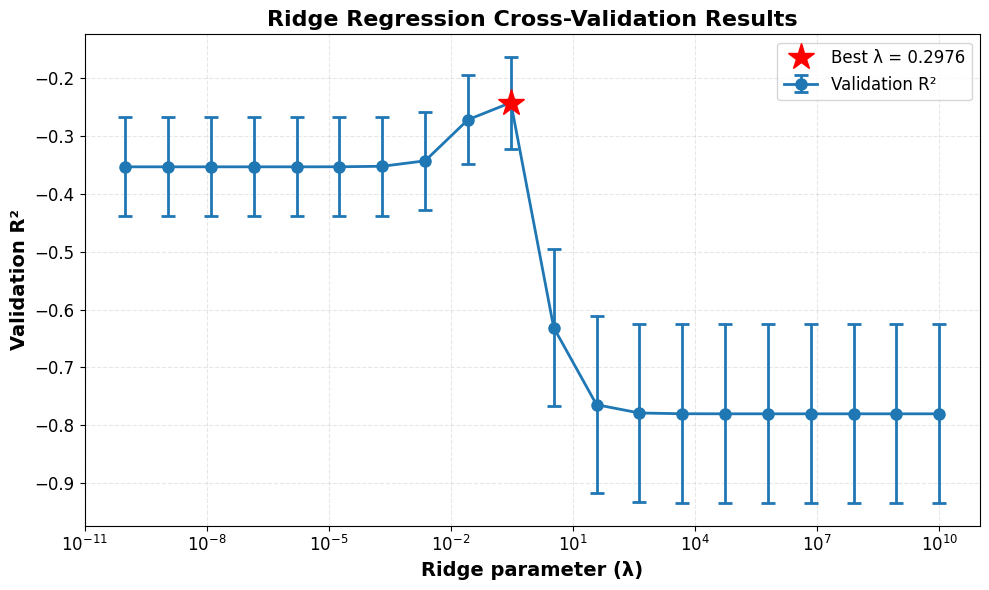

✓ Plotted CV curve
  Best lambda (red star): 0.297635


In [230]:

# Plot Cross-Validation Results

import matplotlib.pyplot as plt

fig, ax = plt.subplots(1, 1, figsize=(10, 6))

# Extract data (sorted by lambda for readability)
lambdas = sorted(cv_results['mean_r2'].keys())
means = [cv_results['mean_r2'][lam] for lam in lambdas]
stds = [cv_results['std_r2'][lam] for lam in lambdas]

# Plot R^2 curve with error bars
ax.errorbar(lambdas, means, yerr=stds, marker='o', markersize=8, 
            capsize=5, capthick=2, linewidth=2, label='Validation R²')

# Mark best lambda
best_idx = lambdas.index(best_lambda)
ax.plot(best_lambda, means[best_idx], 'r*', markersize=20, 
        label=f'Best λ = {best_lambda:.4f}', zorder=5)

# Formatting
ax.set_xscale('log')
ax.set_xlabel('Ridge parameter (λ)', fontsize=14, fontweight='bold')
ax.set_ylabel('Validation R²', fontsize=14, fontweight='bold')
ax.set_title('Ridge Regression Cross-Validation Results', fontsize=16, fontweight='bold')
ax.legend(fontsize=12)
ax.grid(True, alpha=0.3, linestyle='--')
ax.tick_params(labelsize=12)

plt.tight_layout()
plt.show()

print(f"✓ Plotted CV curve")
print(f"  Best lambda (red star): {best_lambda:.6f}")



In [231]:

# 5-Fold CV across regression time bins (contiguous per condition, fixed lambda)

def make_contiguous_folds(n_bins, n_folds=5):
    if n_bins < n_folds:
        raise ValueError(f'Not enough bins ({n_bins}) for {n_folds}-fold CV')
    base = n_bins // n_folds
    remainder = n_bins % n_folds
    sizes = [base + (1 if i < remainder else 0) for i in range(n_folds)]
    folds = []
    start = 0
    for size in sizes:
        end = start + size
        folds.append((start, end))
        start = end
    return folds


def build_timebin_folds(n_conditions, n_bins_per_condition, reg_cols, n_folds=5):
    folds = []
    fold_ranges = make_contiguous_folds(n_bins_per_condition, n_folds=n_folds)
    for fold_start, fold_end in fold_ranges:
        test_local = []
        for cond_idx in range(n_conditions):
            base = cond_idx * n_bins_per_condition
            test_local.extend(range(base + fold_start, base + fold_end))
        test_local = sorted(test_local)
        test_idx = reg_cols[test_local]
        train_idx = np.setdiff1d(reg_cols, test_idx, assume_unique=True)
        folds.append({
            'fold_range': (fold_start, fold_end),
            'train_idx': train_idx,
            'test_idx': test_idx
        })
    return folds


def ridge_fit(M_train, N_train, lam):
    NNT = N_train @ N_train.T
    I_k = lam * np.eye(N_train.shape[0])
    regularized_cov = NNT + I_k
    MNT = M_train @ N_train.T
    return MNT @ np.linalg.solve(regularized_cov, np.eye(N_train.shape[0]))


def r2_score_matrix(y_true, y_pred):
    ss_res = np.sum((y_true - y_pred) ** 2)
    y_true_mean = y_true.mean(axis=1, keepdims=True)
    ss_tot = np.sum((y_true - y_true_mean) ** 2)
    if ss_tot == 0:
        return np.nan
    return 1 - ss_res / ss_tot

print('=== Contiguous 5-Fold CV across regression time bins (per condition, fixed λ) ===')
reg_cols = np.where(idx_regression)[0]
n_reg_cols = len(reg_cols)
if n_reg_cols < 5:
    raise ValueError('Need at least 5 regression columns for 5-fold CV')

n_conditions_reg = len(condition_info_regression) if condition_info_regression is not None else None
if n_conditions_reg is None or n_conditions_reg == 0:
    raise ValueError('condition_info_regression is missing; cannot build condition-wise folds.')
if n_reg_cols % n_conditions_reg != 0:
    raise ValueError('Regression columns are not evenly divisible by conditions; check column structure.')

n_bins_per_condition_reg = n_reg_cols // n_conditions_reg
print(f'Regression columns: {n_reg_cols}, conditions: {n_conditions_reg}, bins/condition: {n_bins_per_condition_reg}')

if 'best_lambda' not in globals():
    raise ValueError('best_lambda is not defined; run the global lambda CV first.')
lambda_used = float(best_lambda)
print(f'Using fixed λ from global CV: {lambda_used:.4e}')

folds = build_timebin_folds(n_conditions_reg, n_bins_per_condition_reg, reg_cols, n_folds=5)
fold_r2 = []
fold_lambdas = []
for fold_idx, fold in enumerate(folds, 1):
    train_idx = fold['train_idx']
    test_idx = fold['test_idx']
    N_train_fold = pc_matrix_source[:, train_idx]
    M_train_fold = pc_matrix_target[:, train_idx]

    W_fold = ridge_fit(M_train_fold, N_train_fold, lambda_used)
    N_test_fold = pc_matrix_source[:, test_idx]
    M_test_fold = pc_matrix_target[:, test_idx]
    M_pred_fold = W_fold @ N_test_fold
    r2_val = r2_score_matrix(M_test_fold, M_pred_fold)

    fold_r2.append(r2_val)
    fold_lambdas.append(lambda_used)
    fold_start, fold_end = fold['fold_range']
    print(f'Fold {fold_idx}: held-out bins per condition = [{fold_start}, {fold_end}), λ = {lambda_used:.4e}, R^2 = {r2_val:.4f}')

cv_r2_mean = np.nanmean(fold_r2) if len(fold_r2) > 0 else np.nan
print()
print(f'Average R^2 across folds (outer test): {cv_r2_mean:.4f}')

# Store CV results
ridge_timebin_cv = {
    'folds': folds,
    'fold_r2': fold_r2,
    'fold_lambdas': fold_lambdas,
    'mean_r2': cv_r2_mean,
    'lambda_used': lambda_used
}



=== Contiguous 5-Fold CV across regression time bins (per condition, fixed λ) ===
Regression columns: 80, conditions: 5, bins/condition: 16
Using fixed λ from global CV: 2.9764e-01
Fold 1: held-out bins per condition = [0, 4), λ = 2.9764e-01, R^2 = -0.2143
Fold 2: held-out bins per condition = [4, 7), λ = 2.9764e-01, R^2 = -0.1816
Fold 3: held-out bins per condition = [7, 10), λ = 2.9764e-01, R^2 = -0.3751
Fold 4: held-out bins per condition = [10, 13), λ = 2.9764e-01, R^2 = -0.2866
Fold 5: held-out bins per condition = [13, 16), λ = 2.9764e-01, R^2 = -0.1564

Average R^2 across folds (outer test): -0.2428


In [ ]:
# Step 3: Implement Ridge Regression (with CV-selected parameter)
# Ridge regression: M ≈ W * N
# W = (M_train @ N_train.T) @ inv(N_train @ N_train.T + lam * I_k_source)
# Shape: (k_target, k_source)

# Use best lambda from cross-validation
lam = best_lambda

print("=== Ridge Regression Setup ===")
print(f"Ridge parameter λ: {lam:.6f} (selected via 5-fold CV)")
print(f"N_train shape: {N_train.shape} (k_source × num_fit_cols)")
print(f"M_train shape: {M_train.shape} (k_target × num_fit_cols)")

# Compute components of ridge regression formula
# N_train @ N_train.T: shape (k_source, k_source)
NNT = N_train @ N_train.T

# Identity matrix scaled by lambda: λ * I_k_source
I_k = lam * np.eye(N_train.shape[0])  # N_train.shape[0] = k_source

# Regularized covariance: N_train @ N_train.T + λ * I_k_source
regularized_cov = NNT + I_k

# M_train @ N_train.T: shape (k_target, k_source)
MNT = M_train @ N_train.T

# Compute W using numerically stable solve (instead of inverse)
# W = MNT @ inv(regularized_cov) 
# More stable: W = MNT @ solve(regularized_cov, I)
W = MNT @ np.linalg.solve(regularized_cov, np.eye(N_train.shape[0]))

print(f"\n=== Ridge Regression Results ===")
print(f"W shape: {W.shape} (k_target × k_source)")
print(f"  k_target: {W.shape[0]}")
print(f"  k_source: {W.shape[1]}")
print(f"\nW statistics:")
print(f"  Mean: {W.mean():.6f}")
print(f"  Std: {W.std():.6f}")
print(f"  Min: {W.min():.6f}")
print(f"  Max: {W.max():.6f}")
print(f"\n✓ Ridge regression completed (CV-optimized, numerically stable)")


In [ ]:
# Step 4: Store and Verify Results

# Store W matrix and ridge parameter
W_matrix = W
lambda_ridge_value = lam

print("=== Stored Ridge Regression Results ===")
print(f"W_matrix shape: {W_matrix.shape} (k_target × k_source)")
print(f"  k_target: {W_matrix.shape[0]}")
print(f"  k_source: {W_matrix.shape[1]}")
print(f"\nLambda (ridge parameter): {lambda_ridge_value}")
print(f"\nW_matrix statistics:")
print(f"  Mean: {W_matrix.mean():.6f}")
print(f"  Std: {W_matrix.std():.6f}")
print(f"  Min: {W_matrix.min():.6f}")
print(f"  Max: {W_matrix.max():.6f}")

# Verify dimensions
assert W_matrix.shape == (k_target, k_source), \
    f"W_matrix shape mismatch: expected ({k_target}, {k_source}), got {W_matrix.shape}"

print(f"\n✓ W matrix stored and verified")
print(f"  Ready for null space projection")


## 9. SVD of Ridge Mapping (Potent & Null Bases)

Decompose the ridge-derived mapping `W_tilde` (from Section 8) to identify potent vs null subspaces on the source side, then project the source latent trajectories into those coordinates.

In [ ]:
# SVD of ridge-derived mapping (W_tilde) to get potent/null bases in source space
W_tilde = W_matrix  # From Section 8 ridge regression

print("=== SVD of W_tilde (ridge mapping) ===")
print(f"W_tilde shape: {W_tilde.shape} (k_target × k_source)")

U, S, Vt = np.linalg.svd(W_tilde, full_matrices=True)
V = Vt.T  # Right singular vectors (source side)

print(f"U shape: {U.shape} (k_target × k_target)")
print(f"S length: {S.shape} (min(k_target, k_source), )")
print(f"V shape: {V.shape} (k_source × k_source) - right singular vectors")

# Select potent rank based on singular value magnitude (relative threshold)
singular_value_threshold = 1e-3 * S.max() if S.size > 0 else 0.0
r = int(np.sum(S > singular_value_threshold))

if r == 0 and S.size > 0:
    r = 1
    print("All singular values below threshold; forcing r=1 to keep leading potent dimension.")
elif S.size == 0:
    r = 0
    print("Warning: no singular values returned; setting r=0.")

V_pot = V[:, :r] if r > 0 else np.empty((V.shape[0], 0))
V_null = V[:, r:] if r < V.shape[1] else np.empty((V.shape[0], 0))
U_pot = U[:, :r] if r > 0 else np.empty((U.shape[0], 0))
U_null = U[:, r:] if r < U.shape[0] else np.empty((U.shape[0], 0))

print(f"Potent rank r: {r} (threshold = {singular_value_threshold:.6f})")
print(f"V_pot shape: {V_pot.shape} (k_source × r)")
print(f"V_null shape: {V_null.shape} (k_source × {V_null.shape[1]})")
print(f"U_pot shape: {U_pot.shape} (k_target × r)")
print(f"U_null shape: {U_null.shape} (k_target × {U_null.shape[1]})")


In [ ]:
# Plot all right singular vectors V; pad missing singular values with zeros
import matplotlib.pyplot as plt
import numpy as np

num_vec = V.shape[1] if V.size else 0
if num_vec == 0:
    print("No V vectors available; plotting zeros.")
    V_plot = np.zeros((1, 1))
    S_pad = np.zeros(1)
    num_vec = 1
else:
    V_plot = V  # use all columns (potent + null)
    S_pad = np.zeros(num_vec)
    S_pad[: len(S)] = S  # pad remaining singular values with 0

# Normalize sizes; avoid divide-by-zero
s_max = S_pad.max() if S_pad.max() > 0 else 1.0
size_scale = ((S_pad / s_max) ** 2) * 200  # marker area scales with singular values

fig, (ax_v, ax_s) = plt.subplots(1, 2, figsize=(14, 5))

# Bubble plot of V (all columns)
x_idx = np.arange(V_plot.shape[0])
for j in range(num_vec):
    ax_v.scatter(
        x_idx,
        V_plot[:, j],
        s=size_scale[j],
        alpha=0.6,
        label=f"s{j+1} = {S_pad[j]:.3g}",
    )
ax_v.axhline(0, color="k", linewidth=0.8)
ax_v.set_xlabel("Source dimension")
ax_v.set_ylabel("V value")
ax_v.set_title("Right singular vectors V (all columns; size ∝ singular value)")
# Limit legend to avoid overgrowth
if num_vec <= 15:
    ax_v.legend(loc="upper right", fontsize=8)

# Singular values (padded with zeros)
ax_s.bar(range(num_vec), S_pad, color="gray")
ax_s.set_xlabel("Index")
ax_s.set_ylabel("Singular value")
ax_s.set_title("Singular values (padded zeros for extra V columns)")
ax_s.set_xticks(range(num_vec))
ax_s.set_xticklabels([str(i + 1) for i in range(num_vec)])

plt.tight_layout()


In [ ]:
# Project source latent activity into potent & null coordinates
N_lat = pc_matrix_source  # (k_source × T) latent source trajectories (all epochs/conditions)
T_all = N_lat.shape[1]

N_pot = V_pot.T @ N_lat if V_pot.size else np.empty((0, T_all))
N_null = V_null.T @ N_lat if V_null.size else np.empty((0, T_all))

# Store for downstream use
potent_basis_source = V_pot
null_basis_source = V_null
potent_timecourses = N_pot
null_timecourses = N_null

print("=== Potent/Null Projections (source latent space) ===")
print(f"N_lat shape: {N_lat.shape} (k_source × T)")
print(f"N_pot shape: {N_pot.shape} (r × T)")
print(f"N_null shape: {N_null.shape} ((k_source - r) × T)")
print("  Each row is one dimension's timecourse in potent/null space")
print("✓ Potent/null coordinates computed")


## 10. Validate Null Space on Regression Epoch

Check that the null basis from Section 9 is (approximately) in the kernel of `W_tilde` by comparing potent vs null predictions during the regression window.

In [ ]:
# Validate that null space is (approximately) the kernel of W_tilde on regression epoch
W_tilde = W_matrix
N_lat = pc_matrix_source           # Source latent trajectories (k_source × T)
M_lat = pc_matrix_target           # Target latent trajectories (k_target × T)
idx_reg = idx_regression           # Boolean mask for regression columns

# Regression-epoch slices
N_reg = N_lat[:, idx_reg]
N_pot_reg = potent_timecourses[:, idx_reg]
N_null_reg = null_timecourses[:, idx_reg]
M_reg = M_lat[:, idx_reg]

# Full prediction using all source dimensions
M_hat_full = W_tilde @ N_reg  # (k_target × T_reg)

# Potent-only prediction (project back to k_source before applying W_tilde)
N_reg_pot_only = V_pot @ N_pot_reg
M_hat_pot = W_tilde @ N_reg_pot_only

# Null-only prediction
N_reg_null_only = V_null @ N_null_reg
M_hat_null = W_tilde @ N_reg_null_only

# Helper metrics
frob = lambda x: float(np.linalg.norm(x, ord='fro'))

def r2_score_matrix(y_true, y_pred):
    resid = y_true - y_pred
    ss_res = float(np.sum(resid ** 2))
    ss_tot = float(np.sum((y_true - y_true.mean()) ** 2))
    if ss_tot == 0:
        return np.nan
    return 1.0 - ss_res / ss_tot

norm_pot = frob(M_hat_pot)
norm_null = frob(M_hat_null)
r2_pot = r2_score_matrix(M_reg, M_hat_pot)
r2_null = r2_score_matrix(M_reg, M_hat_null)
r2_full = r2_score_matrix(M_reg, M_hat_full)

print("=== Null-space validation (regression epoch) ===")
print(f"Shapes -> N_reg: {N_reg.shape}, M_reg: {M_reg.shape}, W_tilde: {W_tilde.shape}")
print(f"Potent rank r: {V_pot.shape[1]}, Null dims: {V_null.shape[1]}")
print(f"‖M_hat_pot‖_F:  {norm_pot:.6f}")
print(f"‖M_hat_null‖_F: {norm_null:.6f}")
print(f"R^2 (pot vs M_reg):  {r2_pot:.4f}")
print(f"R^2 (null vs M_reg): {r2_null:.4f}")
print(f"R^2 (full vs M_reg): {r2_full:.4f}")

## 11. Potent vs Null Variance
Time-resolved variance in potent vs null subspaces for projection vs regression epochs (source).
Permutation-based null test (potent rank preserved), two-sided p-values, and histograms showing observed vs null distributions.

In [ ]:
# Variance across projection vs regression epochs (time-resolved)
N_lat = pc_matrix_source
idx_reg = idx_regression
idx_proj = idx_project  # projection epoch = prep/delay

# Variance helpers
def var_sum(arr):
    """Sum of per-dimension variance (rows) for a 2D array."""
    return float(np.var(arr, axis=1).sum()) if arr.size else 0.0

# Epoch slices
N_pot_reg = N_pot[:, idx_reg]
N_null_reg = N_null[:, idx_reg]
N_pot_proj = N_pot[:, idx_proj]
N_null_proj = N_null[:, idx_proj]

var_pot_reg = var_sum(N_pot_reg)
var_null_reg = var_sum(N_null_reg)
var_pot_proj = var_sum(N_pot_proj)
var_null_proj = var_sum(N_null_proj)

print("=== Subspace variance by epoch (aggregate) ===")
print(f"Potent dims: {N_pot.shape[0]}, Null dims: {N_null.shape[0]}")
print(f"Regression epoch  -> var_pot: {var_pot_reg:.6f}, var_null: {var_null_reg:.6f}")
print(f"Projection epoch  -> var_pot: {var_pot_proj:.6f}, var_null: {var_null_proj:.6f}")
print("Expectation: movement/regression high in potent; projection/prep high in null or balanced.")

# Time-resolved variance per condition
def var_time_by_condition(X, labels):
    cond_to_cols = {}
    for j, lab in enumerate(labels):
        cond = lab.split('_t')[0] if '_t' in lab else str(lab)
        cond_to_cols.setdefault(cond, []).append(j)
    series = {}
    for cond, cols in cond_to_cols.items():
        cols_sorted = sorted(cols)
        v = np.linalg.norm(X[:, cols_sorted], axis=0) ** 2
        series[cond] = v
    return series

def mean_sem(series_dict):
    if len(series_dict) == 0:
        return None, None, None
    arr = np.stack(list(series_dict.values()))
    mean = arr.mean(axis=0)
    sem = arr.std(axis=0, ddof=1) / np.sqrt(arr.shape[0]) if arr.shape[0] > 1 else np.zeros_like(mean)
    return mean, sem, list(series_dict.keys())

n_cols_total = N_lat.shape[1]
labels_all = np.array([f'col_{i}' for i in range(n_cols_total)], dtype=object)
if 'combined_group_info' in globals() and combined_group_info is not None:
    for name, sl in combined_group_info.items():
        labels_all[sl] = name
elif 'combined_column_labels' in globals() and combined_column_labels is not None and len(combined_column_labels) == n_cols_total:
    labels_all = np.array(combined_column_labels, dtype=object)

labels_proj = labels_all[idx_proj]
labels_reg = labels_all[idx_reg]

var_proj_pot = var_time_by_condition(N_pot_proj, labels_proj)
var_proj_null = var_time_by_condition(N_null_proj, labels_proj)
var_reg_pot = var_time_by_condition(N_pot_reg, labels_reg)
var_reg_null = var_time_by_condition(N_null_reg, labels_reg)

var_proj_pot_mean, var_proj_pot_sem, conds_proj = mean_sem(var_proj_pot)
var_proj_null_mean, var_proj_null_sem, _ = mean_sem(var_proj_null)
var_reg_pot_mean, var_reg_pot_sem, conds_reg = mean_sem(var_reg_pot)
var_reg_null_mean, var_reg_null_sem, _ = mean_sem(var_reg_null)

# Store for plotting in Section 12
var_time_proj = {
    'pot_mean': var_proj_pot_mean,
    'pot_sem': var_proj_pot_sem,
    'null_mean': var_proj_null_mean,
    'null_sem': var_proj_null_sem,
    'conds': conds_proj,
}
var_time_reg = {
    'pot_mean': var_reg_pot_mean,
    'pot_sem': var_reg_pot_sem,
    'null_mean': var_reg_null_mean,
    'null_sem': var_reg_null_sem,
    'conds': conds_reg,
}

# Prep tuning ratio (null vs potent) + time-resolved tuning in projection epoch
conds_proj_unique = np.unique(labels_proj)
if conds_proj_unique.size == 0:
    tuning_ratio = np.nan
    tuning_ratio_t = None
    tuning_time_proj = {'pot': None, 'null': None, 'time_axis': None, 'ratio_t': None}
    print("No projection labels; skipped prep tuning ratio.")
else:
    counts = {cond: int((labels_proj == cond).sum()) for cond in conds_proj_unique}
    unique_counts = set(counts.values())
    if len(unique_counts) != 1:
        raise ValueError(f"Unbalanced projection bins per condition: {counts}")
    T_per_cond = unique_counts.pop()

    N_pot_proj_3d = np.zeros((N_pot.shape[0], len(conds_proj_unique), T_per_cond))
    N_null_proj_3d = np.zeros((N_null.shape[0], len(conds_proj_unique), T_per_cond))
    for ci, cond in enumerate(conds_proj_unique):
        mask = labels_proj == cond
        N_pot_proj_3d[:, ci, :] = N_pot_proj[:, mask]
        N_null_proj_3d[:, ci, :] = N_null_proj[:, mask]

    # Remove condition means (tuning only)
    N_pot_tune = N_pot_proj_3d - N_pot_proj_3d.mean(axis=1, keepdims=True)
    N_null_tune = N_null_proj_3d - N_null_proj_3d.mean(axis=1, keepdims=True)

    pot_norm2 = float(np.sum(N_pot_tune ** 2))
    null_norm2 = float(np.sum(N_null_tune ** 2))
    gamma = (N_null.shape[0] / N_pot.shape[0]) if N_pot.shape[0] > 0 else np.nan
    tuning_ratio = np.nan
    if pot_norm2 > 0 and np.isfinite(gamma) and gamma > 0:
        tuning_ratio = (null_norm2 / pot_norm2) / gamma

    # Time-resolved tuning energy (variance across conditions per time bin)
    tuning_pot_t = np.sum(np.var(N_pot_proj_3d, axis=1), axis=0)
    tuning_null_t = np.sum(np.var(N_null_proj_3d, axis=1), axis=0)
    tuning_ratio_t = np.full_like(tuning_pot_t, np.nan, dtype=float)
    valid = (tuning_pot_t > 0) & np.isfinite(tuning_pot_t) & np.isfinite(tuning_null_t) & np.isfinite(gamma) & (gamma > 0)
    tuning_ratio_t[valid] = (tuning_null_t[valid] / tuning_pot_t[valid]) / gamma

    use_edges = 'bin_edges_projection' in globals() and bin_edges_projection is not None and len(bin_edges_projection) == T_per_cond + 1
    time_axis = 0.5 * (bin_edges_projection[:-1] + bin_edges_projection[1:]) if use_edges else np.arange(T_per_cond)

    tuning_time_proj = {
        'pot': tuning_pot_t,
        'null': tuning_null_t,
        'ratio_t': tuning_ratio_t,
        'time_axis': time_axis,
    }

    print("=== Prep tuning ratio (null vs potent) ===")
    print(f"N_pot_proj_3d shape:  {N_pot_proj_3d.shape}")
    print(f"N_null_proj_3d shape: {N_null_proj_3d.shape}")
    print(f"Frob^2 (potent tuning): {pot_norm2:.6f}")
    print(f"Frob^2 (null tuning):   {null_norm2:.6f}")
    print(f"gamma (null_dims / pot_dims): {gamma:.6f}")
    print(f"Tuning ratio (null vs potent, prep epoch): {tuning_ratio:.6f}")


In [ ]:
# Permutation test: potent/null variance separation using randomized bases (potent rank preserved)
n_permutations = 1000
perm_rng = np.random.default_rng()

print("=== Permutation test: potent/null variance ===")
if V.size == 0:
    print("Skipped: no right singular vectors V available from SVD.")
else:
    perm_var = {
        'reg_pot': [],
        'reg_null': [],
        'proj_pot': [],
        'proj_null': [],
    }

    for perm_idx in range(n_permutations):
        perm_cols = perm_rng.permutation(V.shape[1])
        V_perm = V[:, perm_cols]
        V_pot_perm = V_perm[:, :r] if r > 0 else np.empty((V.shape[0], 0))
        V_null_perm = V_perm[:, r:] if r < V.shape[1] else np.empty((V.shape[0], 0))

        N_pot_perm = V_pot_perm.T @ N_lat if V_pot_perm.size else np.empty((0, N_lat.shape[1]))
        N_null_perm = V_null_perm.T @ N_lat if V_null_perm.size else np.empty((0, N_lat.shape[1]))

        perm_var['reg_pot'].append(var_sum(N_pot_perm[:, idx_reg]))
        perm_var['reg_null'].append(var_sum(N_null_perm[:, idx_reg]))
        perm_var['proj_pot'].append(var_sum(N_pot_perm[:, idx_proj]))
        perm_var['proj_null'].append(var_sum(N_null_perm[:, idx_proj]))

    perm_var = {k: np.asarray(v) for k, v in perm_var.items()}

    obs_var = {
        'reg': {'pot': var_pot_reg, 'null': var_null_reg},
        'proj': {'pot': var_pot_proj, 'null': var_null_proj},
    }

    def p_tails(obs, null):
        if null.size == 0:
            return np.nan, np.nan, np.nan
        p_greater = (np.sum(null >= obs) + 1) / (null.size + 1)
        p_less = (np.sum(null <= obs) + 1) / (null.size + 1)
        p_two = min(1.0, 2 * min(p_greater, p_less))
        return p_greater, p_less, p_two

    p_values = {
        'reg': {
            'pot': dict(zip(['greater', 'less', 'two_sided'], p_tails(obs_var['reg']['pot'], perm_var['reg_pot']))),
            'null': dict(zip(['greater', 'less', 'two_sided'], p_tails(obs_var['reg']['null'], perm_var['reg_null']))),
        },
        'proj': {
            'pot': dict(zip(['greater', 'less', 'two_sided'], p_tails(obs_var['proj']['pot'], perm_var['proj_pot']))),
            'null': dict(zip(['greater', 'less', 'two_sided'], p_tails(obs_var['proj']['null'], perm_var['proj_null']))),
        },
    }

    variance_permutation = {
        'n_permutations': n_permutations,
        'obs_var': obs_var,
        'perm_var': perm_var,
        'p_values': p_values,
        'rank_r': r,
    }

    print(f"Potent rank (r): {r} of k_source={V.shape[1]}")
    print(f"Permutations: {n_permutations}")
    print("Regression epoch:")
    print(f"  Potent: obs {obs_var['reg']['pot']:.6f} | null mean {perm_var['reg_pot'].mean():.6f} | p_two {p_values['reg']['pot']['two_sided']:.3f} (p>={p_values['reg']['pot']['greater']:.3f}, p<={p_values['reg']['pot']['less']:.3f})")
    print(f"  Null:   obs {obs_var['reg']['null']:.6f} | null mean {perm_var['reg_null'].mean():.6f} | p_two {p_values['reg']['null']['two_sided']:.3f} (p>={p_values['reg']['null']['greater']:.3f}, p<={p_values['reg']['null']['less']:.3f})")
    print("Projection epoch:")
    print(f"  Potent: obs {obs_var['proj']['pot']:.6f} | null mean {perm_var['proj_pot'].mean():.6f} | p_two {p_values['proj']['pot']['two_sided']:.3f} (p>={p_values['proj']['pot']['greater']:.3f}, p<={p_values['proj']['pot']['less']:.3f})")
    print(f"  Null:   obs {obs_var['proj']['null']:.6f} | null mean {perm_var['proj_null'].mean():.6f} | p_two {p_values['proj']['null']['two_sided']:.3f} (p>={p_values['proj']['null']['greater']:.3f}, p<={p_values['proj']['null']['less']:.3f})")

    # Histograms of permutation null with observed value marked
    import matplotlib.pyplot as plt
    fig, axs = plt.subplots(2, 2, figsize=(12, 8))
    plot_data = [
        ("Regression potent", perm_var['reg_pot'], obs_var['reg']['pot'], p_values['reg']['pot']['two_sided']),
        ("Regression null", perm_var['reg_null'], obs_var['reg']['null'], p_values['reg']['null']['two_sided']),
        ("Projection potent", perm_var['proj_pot'], obs_var['proj']['pot'], p_values['proj']['pot']['two_sided']),
        ("Projection null", perm_var['proj_null'], obs_var['proj']['null'], p_values['proj']['null']['two_sided']),
    ]
    for ax, (title, dist, obs_val, p_two) in zip(axs.ravel(), plot_data):
        if dist.size == 0:
            ax.text(0.5, 0.5, 'No permutation data', ha='center', va='center')
            ax.set_axis_off()
            continue
        ax.hist(dist, bins=min(10, max(5, dist.size)), color='gray', alpha=0.7)
        ax.axvline(obs_val, color='red', linestyle='--', linewidth=2, label=f"obs = {obs_val:.4g}")
        ax.set_title(f"{title} (p_two={p_two:.3f})")
        ax.set_xlabel('Variance')
        ax.set_ylabel('Count')
        ax.legend(loc='best')
    plt.tight_layout()


## 12. Variance Visualizations (Potent vs Null)

Plots of potent/null variance over time for projection vs regression; source population


In [ ]:
# Visualization: time-resolved variance potent vs null (source)
import matplotlib.pyplot as plt
from matplotlib import cm

t_bins_proj = np.arange(var_time_proj['pot_mean'].shape[0]) if var_time_proj['pot_mean'] is not None else np.array([])
t_bins_reg = np.arange(var_time_reg['pot_mean'].shape[0]) if var_time_reg['pot_mean'] is not None else np.array([])

fig, axs = plt.subplots(1, 2, figsize=(14, 5))
# Projection
if var_time_proj['pot_mean'] is not None:
    axs[0].plot(t_bins_proj, var_time_proj['pot_mean'], label='Potent', color='tab:blue')
    axs[0].fill_between(t_bins_proj,
                        var_time_proj['pot_mean'] - var_time_proj['pot_sem'],
                        var_time_proj['pot_mean'] + var_time_proj['pot_sem'],
                        color='tab:blue', alpha=0.2)
    axs[0].plot(t_bins_proj, var_time_proj['null_mean'], label='Null', color='tab:orange')
    axs[0].fill_between(t_bins_proj,
                        var_time_proj['null_mean'] - var_time_proj['null_sem'],
                        var_time_proj['null_mean'] + var_time_proj['null_sem'],
                        color='tab:orange', alpha=0.2)
    axs[0].set_title('Projection epoch')
else:
    axs[0].text(0.5, 0.5, 'No projection data', ha='center')
    axs[0].set_axis_off()
axs[0].set_xlabel('Time bin (within condition)')
axs[0].set_ylabel('Variance (||V^T N(t)||^2)')
axs[0].legend(frameon=False)

# Regression
if var_time_reg['pot_mean'] is not None:
    axs[1].plot(t_bins_reg, var_time_reg['pot_mean'], label='Potent', color='tab:blue')
    axs[1].fill_between(t_bins_reg,
                        var_time_reg['pot_mean'] - var_time_reg['pot_sem'],
                        var_time_reg['pot_mean'] + var_time_reg['pot_sem'],
                        color='tab:blue', alpha=0.2)
    axs[1].plot(t_bins_reg, var_time_reg['null_mean'], label='Null', color='tab:orange')
    axs[1].fill_between(t_bins_reg,
                        var_time_reg['null_mean'] - var_time_reg['null_sem'],
                        var_time_reg['null_mean'] + var_time_reg['null_sem'],
                        color='tab:orange', alpha=0.2)
    axs[1].set_title('Regression epoch')
else:
    axs[1].text(0.5, 0.5, 'No regression data', ha='center')
    axs[1].set_axis_off()
axs[1].set_xlabel('Time bin (within condition)')
axs[1].set_ylabel('Variance (||V^T N(t)||^2)')
axs[1].legend(frameon=False)

plt.tight_layout()
plt.show()


## 13. Attractor Points + Time Courses (potent vs null)
- 3D condition centroids for projection vs regression in potent/null spaces.
- Time-resolved dim 1–3 trajectories per condition, with regression (left) and projection (right) plotted side-by-side, shared y-axis, same colors per condition.

In [ ]:

# Attractor points (condition centroids) in potent vs null spaces (3D) + time courses for dims 1-3
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import cm

if 'idx_project' not in globals() or 'idx_regression' not in globals():
    raise RuntimeError("idx_project/idx_regression not found; run earlier sections to build epoch masks.")

traj_pot = N_pot if 'N_pot' in globals() else np.empty((0, pc_matrix_source.shape[1]))
traj_null = N_null if 'N_null' in globals() else np.empty((0, pc_matrix_source.shape[1]))

n_cols_total = pc_matrix_source.shape[1]
labels_all = np.array([f'col_{i}' for i in range(n_cols_total)], dtype=object)
if 'combined_group_info' in globals() and combined_group_info is not None:
    for name, sl in combined_group_info.items():
        labels_all[sl] = name
elif 'combined_column_labels' in globals() and combined_column_labels is not None and len(combined_column_labels) == n_cols_total:
    labels_all = np.array(combined_column_labels, dtype=object)


def normalize_cond(label):
    lab = str(label)
    if lab.startswith('projection_'):
        lab = lab[len('projection_'):]
    if lab.startswith('regression_'):
        lab = lab[len('regression_'):]
    if '_t' in lab:
        lab = lab.split('_t')[0]
    return lab

idx_proj_mask = idx_project
idx_reg_mask = idx_regression

cond_to_cols_proj = {}
cond_to_cols_reg = {}
for j, lab in enumerate(labels_all):
    cond = normalize_cond(lab)
    if idx_proj_mask[j]:
        cond_to_cols_proj.setdefault(cond, []).append(j)
    if idx_reg_mask[j]:
        cond_to_cols_reg.setdefault(cond, []).append(j)

conds = sorted(set(cond_to_cols_proj) | set(cond_to_cols_reg))
colors = {cond: cm.tab20(i % 20) for i, cond in enumerate(conds)}
markers = {'proj': 'o', 'reg': '^'}

# 3D centroids
fig = plt.figure(figsize=(14, 6))
ax_pot = fig.add_subplot(1, 2, 1, projection='3d')
ax_null = fig.add_subplot(1, 2, 2, projection='3d')

for cond in conds:
    proj_cols = sorted(cond_to_cols_proj.get(cond, []))
    reg_cols = sorted(cond_to_cols_reg.get(cond, []))

    # Potent (dims 1-3)
    if traj_pot.shape[0] >= 3:
        cent_proj = traj_pot[:3, proj_cols].mean(axis=1) if len(proj_cols) > 0 else None
        cent_reg = traj_pot[:3, reg_cols].mean(axis=1) if len(reg_cols) > 0 else None
        if cent_proj is not None:
            ax_pot.scatter(cent_proj[0], cent_proj[1], cent_proj[2], color=colors[cond], marker=markers['proj'], label=f"{cond} proj")
        if cent_reg is not None:
            ax_pot.scatter(cent_reg[0], cent_reg[1], cent_reg[2], color=colors[cond], marker=markers['reg'], label=f"{cond} reg")
        if cent_proj is not None and cent_reg is not None:
            ax_pot.plot([cent_proj[0], cent_reg[0]], [cent_proj[1], cent_reg[1]], [cent_proj[2], cent_reg[2]], color=colors[cond], alpha=0.6)
    else:
        ax_pot.text2D(0.5, 0.5, 'Potent dim < 3', transform=ax_pot.transAxes)

    # Null (dims 1-3)
    if traj_null.shape[0] >= 3:
        cent_proj = traj_null[:3, proj_cols].mean(axis=1) if len(proj_cols) > 0 else None
        cent_reg = traj_null[:3, reg_cols].mean(axis=1) if len(reg_cols) > 0 else None
        if cent_proj is not None:
            ax_null.scatter(cent_proj[0], cent_proj[1], cent_proj[2], color=colors[cond], marker=markers['proj'], label=f"{cond} proj")
        if cent_reg is not None:
            ax_null.scatter(cent_reg[0], cent_reg[1], cent_reg[2], color=colors[cond], marker=markers['reg'], label=f"{cond} reg")
        if cent_proj is not None and cent_reg is not None:
            ax_null.plot([cent_proj[0], cent_reg[0]], [cent_proj[1], cent_reg[1]], [cent_proj[2], cent_reg[2]], color=colors[cond], alpha=0.6)
    else:
        ax_null.text2D(0.5, 0.5, 'Null dim < 3', transform=ax_null.transAxes)

ax_pot.set_title('Potent attractors (proj vs reg, 3D)')
ax_null.set_title('Null attractors (proj vs reg, 3D)')
for ax in [ax_pot, ax_null]:
    ax.set_xlabel('Dim 1')
    ax.set_ylabel('Dim 2')
    ax.set_zlabel('Dim 3')
    ax.legend(fontsize=8, frameon=False)

plt.tight_layout()
plt.show()

# Time-resolved dim 1-3 per condition, regression (left) vs projection (right), shared y per dim
cond_cols_proj = {c: sorted(v) for c, v in cond_to_cols_proj.items()}
cond_cols_reg = {c: sorted(v) for c, v in cond_to_cols_reg.items()}
cond_union = sorted(set(cond_cols_proj) | set(cond_cols_reg))

if len(cond_union) == 0:
    print("No conditions found for time-resolved plots.")
else:
    def check_lengths(cond_dict):
        if not cond_dict:
            return 0, True
        lengths = [len(v) for v in cond_dict.values()]
        return lengths[0], all(l == lengths[0] for l in lengths)

    T_proj, ok_proj = check_lengths(cond_cols_proj)
    T_reg, ok_reg = check_lengths(cond_cols_reg)

    if not ok_proj or not ok_reg or T_proj == 0 or T_reg == 0:
        print(f"Skipping time-resolved plots (unbalanced or missing lengths): proj T={T_proj}, reg T={T_reg}.")
    else:
        def build_time_axis(bin_edges, T):
            if bin_edges is not None and len(bin_edges) == T + 1:
                t = 0.5 * (bin_edges[:-1] + bin_edges[1:])
                return t - t[0]
            return np.arange(T)

        time_proj = build_time_axis(bin_edges_projection if 'bin_edges_projection' in globals() else None, T_proj)
        time_reg = build_time_axis(bin_edges_regression if 'bin_edges_regression' in globals() else None, T_reg)

        colors_tc = {cond: cm.tab10(i % 10) for i, cond in enumerate(cond_union)}

        def plot_space(name, traj):
            dims = min(3, traj.shape[0])
            if dims == 0:
                print(f"{name}: no dimensions to plot.")
                return
            fig, axes = plt.subplots(dims, 2, figsize=(12, 3 * dims), sharey=True)
            if dims == 1:
                axes = np.array([axes])
            for d in range(dims):
                y_min, y_max = np.inf, -np.inf
                for col_idx, (epoch_name, cond_cols, t_axis) in enumerate([
                    ('Regression', cond_cols_reg, time_reg),
                    ('Projection', cond_cols_proj, time_proj),
                ]):
                    ax = axes[d, col_idx]
                    for cond in cond_union:
                        cols = cond_cols.get(cond, [])
                        if len(cols) == 0:
                            continue
                        series = traj[d, cols]
                        L = min(len(series), len(t_axis))
                        series = series[:L]
                        ax.plot(t_axis[:L], series, label=cond, color=colors_tc[cond], linestyle='-' if epoch_name == 'Projection' else '--')
                        if series.size:
                            y_min = min(y_min, float(series.min()))
                            y_max = max(y_max, float(series.max()))
                    ax.set_title(f"{name} dim {d+1} ({epoch_name})")
                    ax.set_xlabel(f"{epoch_name} time (s)")
                axes[d, 0].set_ylabel(f"{name} dim {d+1}")
                if np.isfinite(y_min) and np.isfinite(y_max):
                    for col_idx in range(2):
                        axes[d, col_idx].set_ylim(y_min, y_max)
            axes[0, 1].legend(title='Condition', frameon=False, fontsize=8)
            fig.suptitle(f"{name} dims 1-3: regression (left) vs projection (right)", y=0.98)
            plt.tight_layout(rect=[0, 0, 1, 0.96])
            plt.show()

        plot_space('Potent', traj_pot)
        plot_space('Null', traj_null)
